## Bayesian Optimization for Enzyme Catalysis (1 dimensional problem) ##

### 1. BoTorch ###

In [1]:
import os
import torch 
import pandas as pd
import numpy as np
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from torch.distributions import MultivariateNormal
from botorch import fit_gpytorch_mll
from botorch.models.gp_regression import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize 
from botorch.acquisition import qLogNoisyExpectedImprovement, qNoisyExpectedImprovement
from botorch.acquisition.analytic import NoisyExpectedImprovement, LogNoisyExpectedImprovement
from botorch.sampling.get_sampler import SobolQMCNormalSampler
from botorch.optim import optimize_acqf
from botorch.acquisition.objective import GenericMCObjective
from gpytorch.mlls.exact_marginal_log_likelihood import ExactMarginalLogLikelihood
from gpytorch.mlls.sum_marginal_log_likelihood import SumMarginalLogLikelihood

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
from typing import Union, Optional, List, Tuple

def _transform_tensor(args):

    if len(args) != 2 :

        raise ValueError('The given tuple must have only two tensors, one corresponding to X_obs and the other one to Y_obs')
        
    if not (isinstance(args[0], torch.Tensor) or isinstance(args[1], torch.Tensor)):

        raise ValueError('All elements of the given tuple must be a tensor')
        
    if not (args[0].ndim == 2 or args[1].ndim == 2):

        raise ValueError('Tensors must be of two dimensions')
        
    if not (args[0].shape[0] == args[1].shape[0]):

        raise ValueError('Both tensors must be of the same length')
        
    return (args[0], args[1])

def _transform_dataframe(args, target, usecols):

    return None 

def _import_data(args, target, usecols):

    return None

class BayesOptN:
    """
    ... On en parlera après 
    """

    def __init__(
            self, 
            data:Union[pd.DataFrame, Tuple[torch.Tensor, torch.Tensor], str],
            bounds:torch.Tensor,
            target:Optional[str],
            usecols:Optional[List[Tuple]],
            objective:Optional[function],
            n_iter:Optional[int],
            ACP_Analysis:False,
            acq_function:str='qEI',
            loglld = None
            ) -> None:
        
        self.check_parameters()
        self.initialize_model()
        if isinstance(objective, function):
            self.loop_optimize()
        else:
            self.get_suggestion()


    def check_parameters(self) -> None : 
        if isinstance(self.data, Tuple):
            self.input, self.output = _transform_tensor(self.data)
        if isinstance(self.data, pd.DataFrame):
            self.input, self.output = _transform_dataframe(self.data, self.target, self.usecols)
        if isinstance(self.data, str):
            self.input, self.output = _import_data(self.data, self.target, self.usecols)
        ...
 
    def get_suggestion(self) -> None : 
        self.next_x = None 

    def loop_optimize(self) -> None :
        for i in self.n_iter:
            self.res = None 

    def initialize_model(self) -> None:
        self.model = SingleTaskGP(
            train_X = self.input,
            train_Y = self.y_obs,
            input_transform = Normalize(d = self.input.shape[1]),
            outcome_transform = Standardize(m = self.y_obs.shape[1])
        )
        self.mll = self.loglld(self.model.likelihood, self.model)
    




In [2]:
np_rng = np.random.default_rng(seed=123) # To ensure reproducibility 
np.random.seed(42) # To ensure reproducibility 

bounds = torch.tensor([[0.], [10.]], dtype=float)

NUM_RESTARTS = 10
BATCH_SIZE = 1
MC_SAMPLES = 32
RAW_SAMPLES = 32

def fraction_active_true(x, pK = [1.6, 5.0], U=100):

    f1 = 1./(1 + 10**(pK[0]-x))
    f2 = 1./(1 + 10**(x-pK[1]))
    
    return U*f1*f2

def fraction_active(x, pK = [1.6, 5.0], U=100):

    f1 = 1./(1 + 10**(pK[0]-x))
    f2 = 1./(1 + 10**(x-pK[1]))
    
    return U*f1*f2 + np_rng.normal(size=f1.shape)

def initialize_model(X, Y):
    model = SingleTaskGP(train_X = X, train_Y = Y, input_transform=Normalize(d=X.shape[1]), outcome_transform = Standardize(m=Y.shape[1]))
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    return model, mll

def optimize_acqf_and_get_observation(acq_func, bounds):
    """
    This function optimizes the acquisition function, and returns a new candidate and a noisy observation.
    Args:
        acq_func: acquisition function
        bounds: research space

    Returns:
        new candidate
    """
    #optimize
    candidate, _ = optimize_acqf(
        acq_function=acq_func,
        bounds = bounds,
        q=BATCH_SIZE,
        num_restarts=NUM_RESTARTS,
        raw_samples=RAW_SAMPLES,
        options={"batch_limit": 5, "maxiter": 200},
    )
    
    new_x = candidate.detach()
    new_y = fraction_active(new_x)

    return new_x, new_y

def plot_gp_and_acquisition(model, acquisition_func, bounds, train_x, train_y, title="GP et Fonction d'Acquisition"):
    """
    Visualise le modèle GP, l'incertitude et la fonction d'acquisition
    
    Args:
        model: modèle GP BoTorch
        acquisition_func: fonction d'acquisition
        bounds: limites de l'espace de recherche
        train_x: points d'entraînement (input)
        train_y: points d'entraînement (output)
        title: titre du graphique
    """
    # Créer une grille de points pour l'évaluation
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 100).unsqueeze(-1)
    
    # Mettre le modèle en mode évaluation
    model.eval()
    
    with torch.no_grad():
        # Prédictions du GP
        posterior = model.posterior(x_test)
        mean = posterior.mean.squeeze()
        variance = posterior.variance.squeeze()
        std = torch.sqrt(variance)
        
        # Calculer la fonction d'acquisition
        acq_values = acquisition_func(x_test.unsqueeze(1))
    
    # Convertir en numpy pour matplotlib
    x_np = x_test.squeeze().numpy()
    mean_np = mean.numpy()
    std_np = std.numpy()
    train_x_np = train_x.squeeze().numpy()
    train_y_np = train_y.squeeze().numpy()
    acq_np = acq_values.squeeze().numpy()
    
    # Créer le graphique avec deux sous-graphiques
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Graphique 1: GP mean et incertitude
    ax1.plot(x_np, mean_np, 'b-', label='GP Mean', linewidth=2)
    ax1.fill_between(x_np, mean_np - 2*std_np, mean_np + 2*std_np, 
                     alpha=0.3, color='blue', label='±2σ (95% CI)')
    ax1.scatter(train_x_np, train_y_np, c='red', s=50, zorder=5, label='Observations')
    
    # Ajouter la vraie fonction si disponible
    x_true = np.linspace(bounds[0].item(), bounds[1].item(), 100)
    y_true = fraction_active_true(x_true)
    ax1.plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction', linewidth=2)
    
    ax1.set_ylabel('Velocity')
    ax1.set_title(f'{title} - Processus Gaussien')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Graphique 2: Fonction d'acquisition
    ax2.plot(x_np, acq_np, 'purple', linewidth=2, label='Fonction d\'acquisition')
    
    # Gérer le remplissage pour les valeurs négatives et positives
    ax2.fill_between(x_np, 0, acq_np, where=(acq_np >= 0), alpha=0.3, color='purple', interpolate=True)
    ax2.fill_between(x_np, acq_np.min(), acq_np, where=(acq_np <= 0), alpha=0.3, color='purple', interpolate=True)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    ax2.set_xlabel('pH')
    ax2.set_ylabel('Valeur d\'acquisition')
    ax2.set_title('Fonction d\'Acquisition')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Fonction pour comparer les deux méthodes côte à côte
def compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
                   train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei):
    """
    Compare les deux méthodes d'optimisation bayésienne côte à côte
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Créer une grille de points pour l'évaluation
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 100).unsqueeze(-1)
    
    # Évaluer les modèles
    model_nei.eval()
    model_lognei.eval()
    
    with torch.no_grad():
        # Prédictions qNEI
        posterior_nei = model_nei.posterior(x_test)
        mean_nei = posterior_nei.mean.squeeze()
        std_nei = torch.sqrt(posterior_nei.variance.squeeze())
        acq_nei = qNEI(x_test.unsqueeze(1)).squeeze()
        
        # Prédictions qLogNEI
        posterior_lognei = model_lognei.posterior(x_test)
        mean_lognei = posterior_lognei.mean.squeeze()
        std_lognei = torch.sqrt(posterior_lognei.variance.squeeze())
        acq_lognei = qlogNEI(x_test.unsqueeze(1)).squeeze()
    
    # Convertir en numpy
    x_np = x_test.squeeze().numpy()
    x_true = np.linspace(bounds[0].item(), bounds[1].item(), 100)
    y_true = fraction_active_true(x_true)
    
    # Graphique 1: GP qNEI
    axes[0,0].plot(x_np, mean_nei.numpy(), 'b-', label='GP Mean', linewidth=2)
    axes[0,0].fill_between(x_np, (mean_nei - 2*std_nei).numpy(), (mean_nei + 2*std_nei).numpy(), 
                          alpha=0.3, color='blue', label='±2σ')
    axes[0,0].scatter(train_x_nei.squeeze().numpy(), y_obs_nei.squeeze().numpy(), 
                     c='red', s=50, zorder=5, label='Observations')
    axes[0,0].plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction')
    axes[0,0].set_title('qNEI - Processus Gaussien')
    axes[0,0].set_ylabel('Velocity')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Graphique 2: GP qLogNEI
    axes[0,1].plot(x_np, mean_lognei.numpy(), 'b-', label='GP Mean', linewidth=2)
    axes[0,1].fill_between(x_np, (mean_lognei - 2*std_lognei).numpy(), (mean_lognei + 2*std_lognei).numpy(), 
                          alpha=0.3, color='blue', label='±2σ')
    axes[0,1].scatter(train_x_lognei.squeeze().numpy(), y_obs_lognei.squeeze().numpy(), 
                     c='red', s=50, zorder=5, label='Observations')
    axes[0,1].plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction')
    axes[0,1].set_title('qLogNEI - Processus Gaussien')
    axes[0,1].set_ylabel('Velocity')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Graphique 3: Acquisition qNEI
    axes[1,0].plot(x_np, acq_nei.numpy(), 'purple', linewidth=2)
    acq_nei_np = acq_nei.numpy()
    axes[1,0].fill_between(x_np, 0, acq_nei_np, where=(acq_nei_np >= 0), alpha=0.3, color='purple', interpolate=True)
    axes[1,0].fill_between(x_np, 0, acq_nei_np, where=(acq_nei_np < 0), alpha=0.3, color='red', interpolate=True)
    axes[1,0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1,0].set_title('qNEI - Fonction d\'Acquisition')
    axes[1,0].set_xlabel('pH')
    axes[1,0].set_ylabel('Valeur d\'acquisition')
    axes[1,0].grid(True, alpha=0.3)
    
    # Graphique 4: Acquisition qLogNEI
    axes[1,1].plot(x_np, acq_lognei.numpy(), 'purple', linewidth=2)
    acq_lognei_np = acq_lognei.numpy()
    axes[1,1].fill_between(x_np, acq_lognei_np.min(), acq_lognei_np, alpha=0.3, color='purple', interpolate=True)
    axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1,1].set_title('qLogNEI - Fonction d\'Acquisition')
    axes[1,1].set_xlabel('pH')
    axes[1,1].set_ylabel('Valeur d\'acquisition')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Analyser les valeurs des fonctions d'acquisition
def analyze_acquisition_functions(model_nei, model_lognei, qNEI, qlogNEI, bounds):
    """
    Analyse les propriétés des fonctions d'acquisition
    """
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 100).unsqueeze(-1)
    
    model_nei.eval()
    model_lognei.eval()
    
    with torch.no_grad():
        acq_nei = qNEI(x_test.unsqueeze(1)).squeeze()
        acq_lognei = qlogNEI(x_test.unsqueeze(1)).squeeze()
    
    print("=== Analyse des fonctions d'acquisition ===")
    print(f"qNEI:")
    print(f"  - Min: {acq_nei.min().item():.6f}")
    print(f"  - Max: {acq_nei.max().item():.6f}")
    print(f"  - Moyenne: {acq_nei.mean().item():.6f}")
    print(f"  - Valeurs négatives: {(acq_nei < 0).sum().item()}/{len(acq_nei)}")
    
    print(f"\nqLogNEI:")
    print(f"  - Min: {acq_lognei.min().item():.6f}")
    print(f"  - Max: {acq_lognei.max().item():.6f}")
    print(f"  - Moyenne: {acq_lognei.mean().item():.6f}")
    print(f"  - Valeurs négatives: {(acq_lognei < 0).sum().item()}/{len(acq_lognei)}")
    
    # Trouver les maxima
    argmax_nei = x_test[acq_nei.argmax()].item()
    argmax_lognei = x_test[acq_lognei.argmax()].item()
    
    print(f"\nProchain point suggéré:")
    print(f"  - qNEI: pH = {argmax_nei:.3f} (valeur = {acq_nei.max().item():.6f})")
    print(f"  - qLogNEI: pH = {argmax_lognei:.3f} (valeur = {acq_lognei.max().item():.6f})")

# Analyser la convergence des points d'observation
def plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei):
    """
    Visualise la convergence des deux méthodes d'optimisation
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # qNEI convergence
    iterations = range(len(train_x_nei))
    max_values_nei = [y_obs_nei[:i+1].max().item() for i in iterations]
    
    ax1.plot(iterations, max_values_nei, 'bo-', label='qNEI')
    ax1.set_xlabel('Itération')
    ax1.set_ylabel('Meilleure valeur trouvée')
    ax1.set_title('Convergence qNEI')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # qLogNEI convergence
    iterations_log = range(len(train_x_lognei))
    max_values_lognei = [y_obs_lognei[:i+1].max().item() for i in iterations_log]
    
    ax2.plot(iterations_log, max_values_lognei, 'ro-', label='qLogNEI')
    ax2.set_xlabel('Itération')
    ax2.set_ylabel('Meilleure valeur trouvée')
    ax2.set_title('Convergence qLogNEI')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les statistiques
    print(f"qNEI - Meilleure valeur: {max(max_values_nei):.3f}")
    print(f"qLogNEI - Meilleure valeur: {max(max_values_lognei):.3f}")
    print(f"qNEI - Points explorés: {len(train_x_nei)}")
    print(f"qLogNEI - Points explorés: {len(train_x_lognei)}")

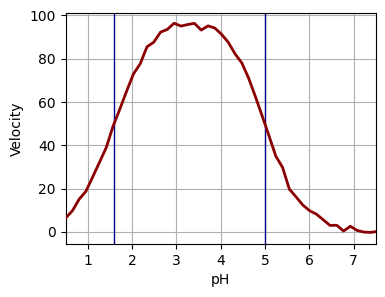

In [3]:
pH = np.linspace(0.5, 8.0, 50)
pK = [1.6, 5.0]
y_true = fraction_active_true(pH)

fig, ax = plt.subplots(figsize=(4,3))
#ax.scatter(pH, fraction_active(pH), s=10, color='darkred', zorder=5)
ax.plot(pH, fraction_active(pH), color='darkred', lw=2, zorder=5)
ax.set_xlabel('pH')
ax.set_ylabel('Velocity')
ax.set_xlim(0.5, 7.5)
ax.grid(True)
ax.axvline(pK[0], 0, 100, color='darkblue', lw=1)
ax.axvline(pK[1], 0, 100, color='darkblue', lw=1)
plt.show()

In [ ]:
# 2 Initial Points

x = np.linspace(0, 8, 2)
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []
iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_25628\3018739214.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return U*f1*f2 + np_rng.normal(size=f1.shape)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_25628\3018739214.py:22: DeprecationWarning: __array_wrap__ must accept context and retu

=== Comparaison des méthodes qNEI et qLogNEI ===


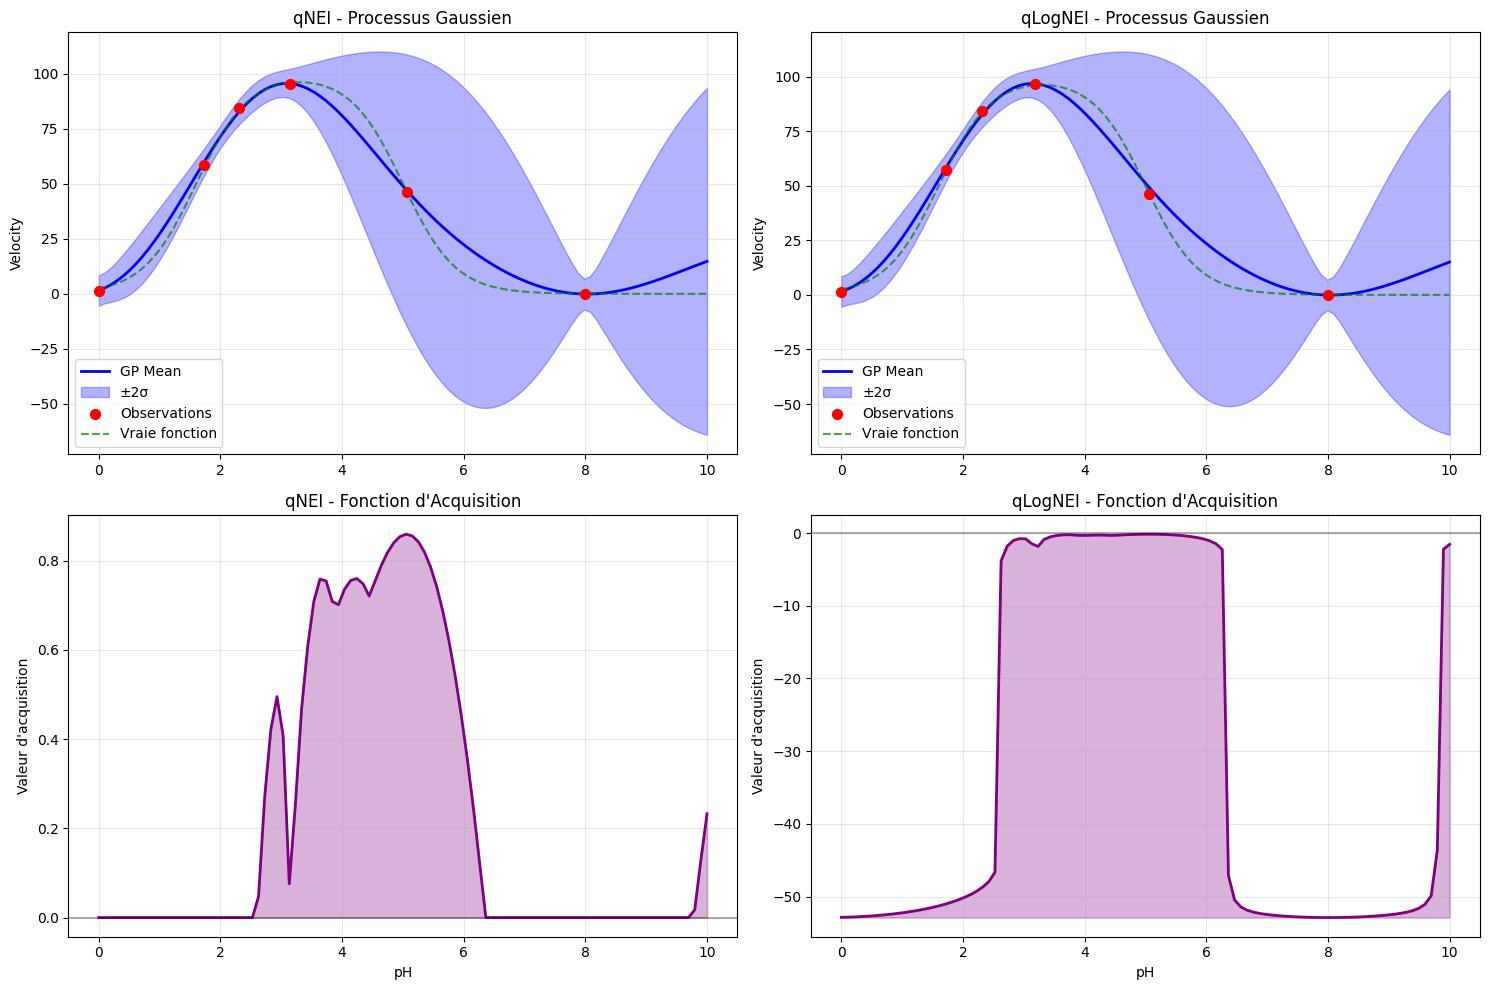

In [24]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

=== Analyse de la convergence === with MC_SAMPLES = 500


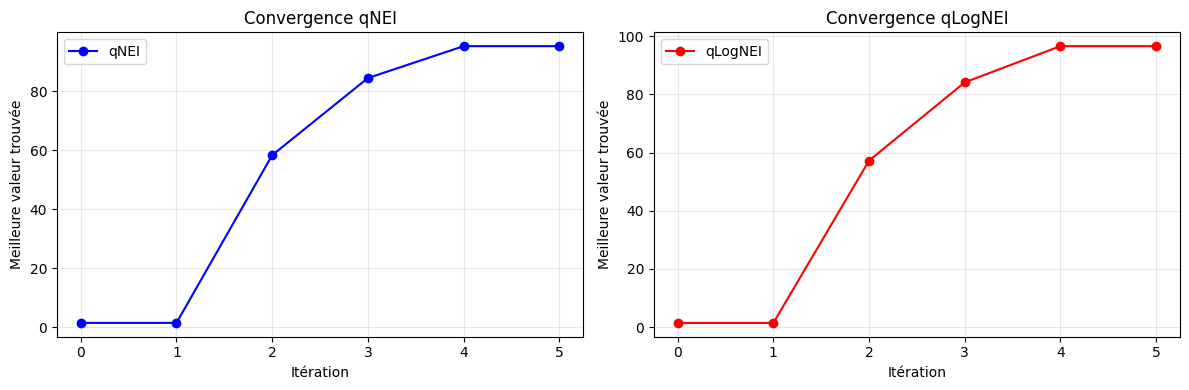

qNEI - Meilleure valeur: 95.258
qLogNEI - Meilleure valeur: 96.536
qNEI - Points explorés: 6
qLogNEI - Points explorés: 6
=== Analyse des fonctions d'acquisition ===
qNEI:
  - Min: 0.000000
  - Max: 0.859331
  - Moyenne: 0.227598
  - Valeurs négatives: 0/100

qLogNEI:
  - Min: -52.887591
  - Max: -0.160625
  - Moyenne: -31.806817
  - Valeurs négatives: 100/100

Prochain point suggéré:
  - qNEI: pH = 5.051 (valeur = 0.859331)
  - qLogNEI: pH = 5.051 (valeur = -0.160625)


In [25]:
# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 500")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)
# Analyser les fonctions d'acquisition
analyze_acquisition_functions(model_nei, model_lognei, qNEI, qlogNEI, bounds)

In [28]:
# 2 Initial Point - Increasing MC Samples 

MC_SAMPLES = 512 

x = np.linspace(0, 8, 2)
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []

iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })
x = np.linspace(0, 8, 2)
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []
iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_25628\3018739214.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return U*f1*f2 + np_rng.normal(size=f1.shape)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_25628\3018739214.py:22: DeprecationWarning: __array_wrap__ must accept context and retu

=== Analyse de la convergence === with MC_SAMPLES = 512


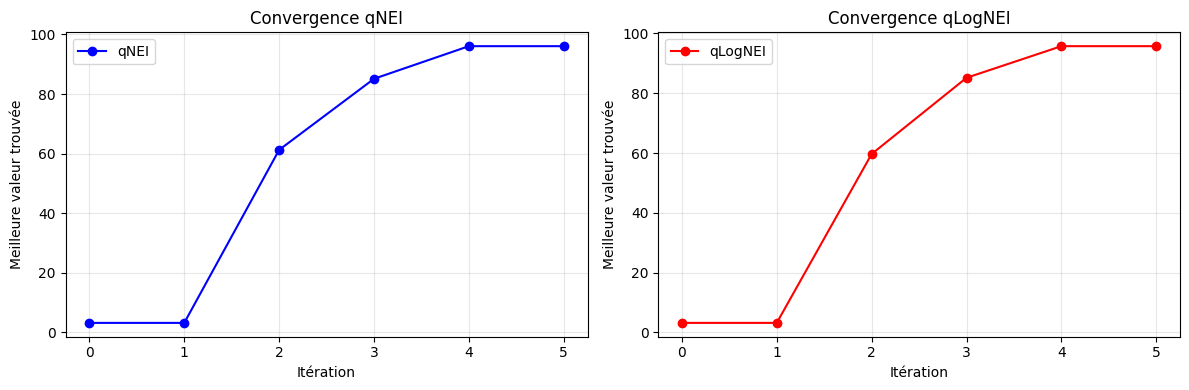

qNEI - Meilleure valeur: 96.057
qLogNEI - Meilleure valeur: 95.733
qNEI - Points explorés: 6
qLogNEI - Points explorés: 6


In [30]:
# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 512")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [12]:
# 1 Initial Point

x = np.random.randint(low=0, high=11, size=(1,))
x = np.array(float(x[0]), dtype='float64')
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []

iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\models\utils\assorted.py:270: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local

=== Comparaison des méthodes qNEI et qLogNEI ===


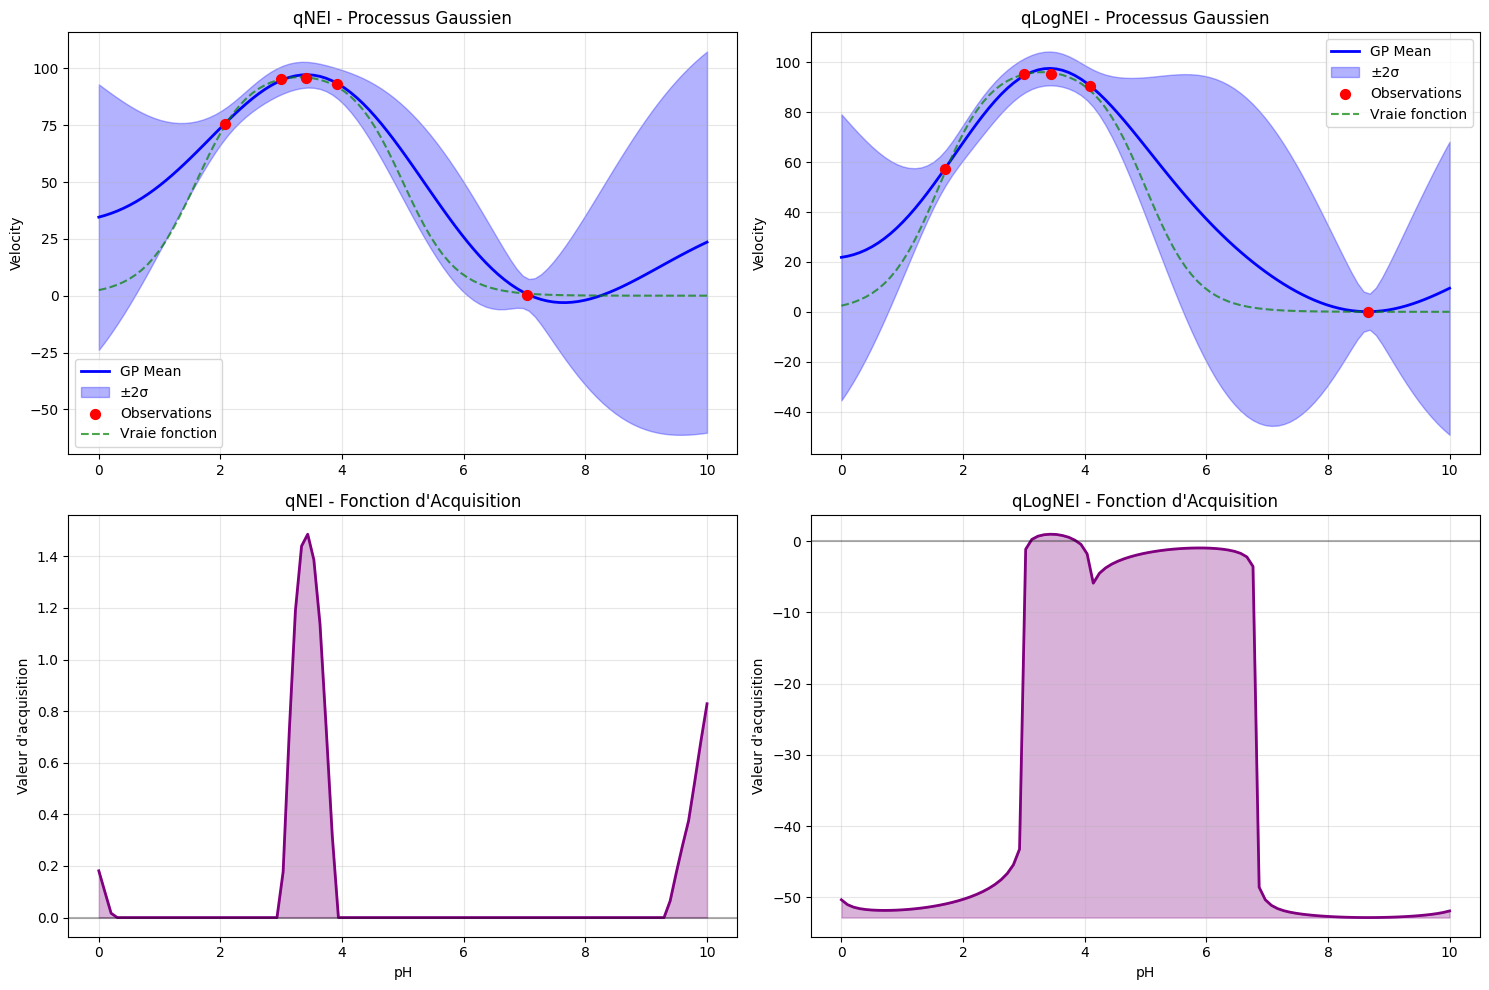

In [13]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

=== Analyse de la convergence === with MC_SAMPLES = 32


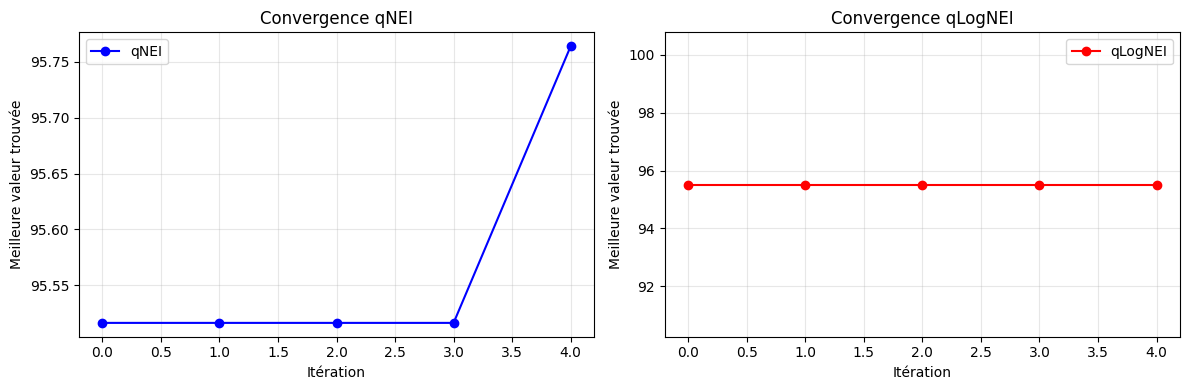

qNEI - Meilleure valeur: 95.764
qLogNEI - Meilleure valeur: 95.516
qNEI - Points explorés: 5
qLogNEI - Points explorés: 5


In [14]:
# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 32")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [44]:
# 1 Initial Point - Increasing MC_SAMPLES

MC_SAMPLES = 512 
x = np.random.randint(low=0, high=11, size=(1,))
x = np.array(float(x[0]), dtype='float64')
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []

iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\models\utils\assorted.py:270: InputDataWarning: Data (input features) is not contained to the unit cube. Please consider min-max scaling the input data.
  check_min_max_scaling(
c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local

=== Analyse de la convergence === with MC_SAMPLES = 512


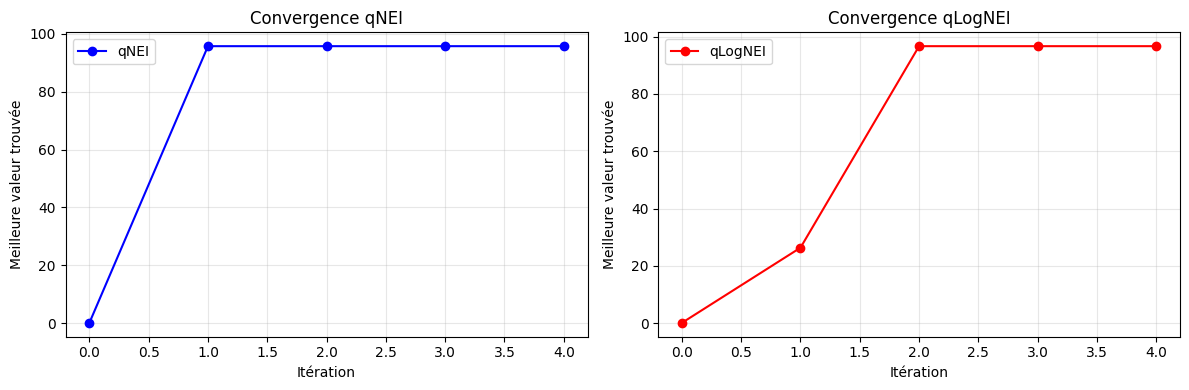

qNEI - Meilleure valeur: 95.760
qLogNEI - Meilleure valeur: 96.656
qNEI - Points explorés: 5
qLogNEI - Points explorés: 5


In [45]:
# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 512")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [10]:
np.array([float(i) for i in x], dtype='float64')

array([4., 6., 9., 2.])

In [5]:
x = np.random.randint(low=0, high=11, size=(4,))
#x = np.array(float(x[0]), dtype='float64')


In [12]:
# 4 Initial Point - Random Points

MC_SAMPLES = 512 

x = np.random.randint(low=0, high=11, size=(4,))
z = np.array([float(i) for i in x], dtype='float64')
y = fraction_active(z)
train_x_nei= torch.tensor(z.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(z.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []

iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
C:\Users\L1116597\AppData\Local\Temp\ipykernel_29948\1221819835.py:23: DeprecationWarning: _

=== Comparaison des méthodes qNEI et qLogNEI ===


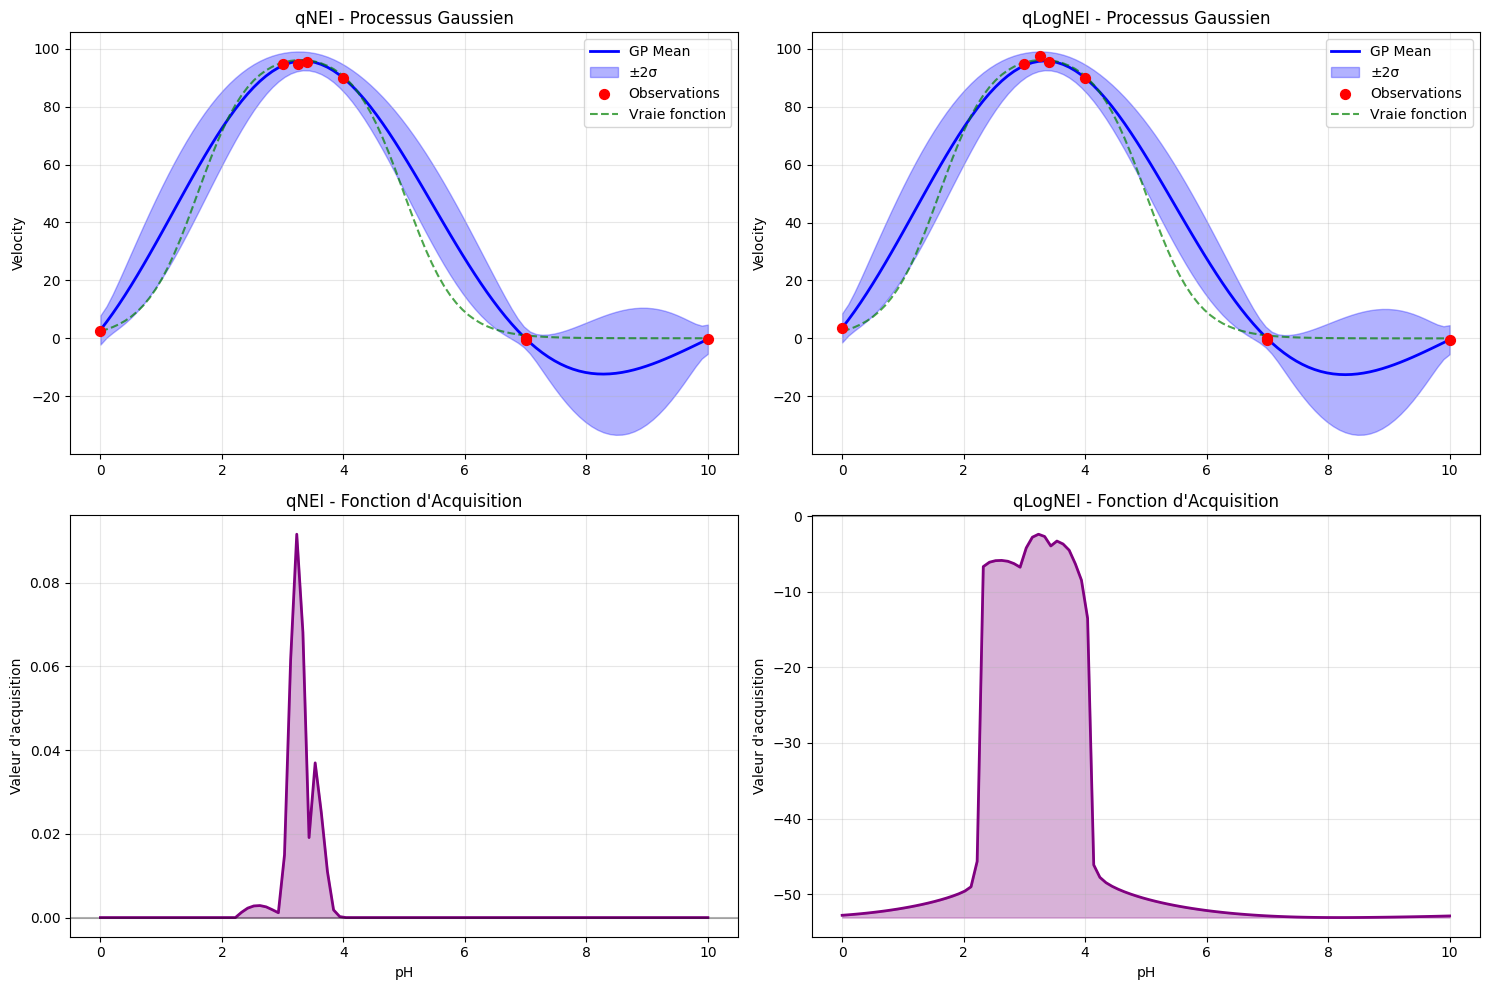

In [13]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

=== Analyse de la convergence === with MC_SAMPLES = 512


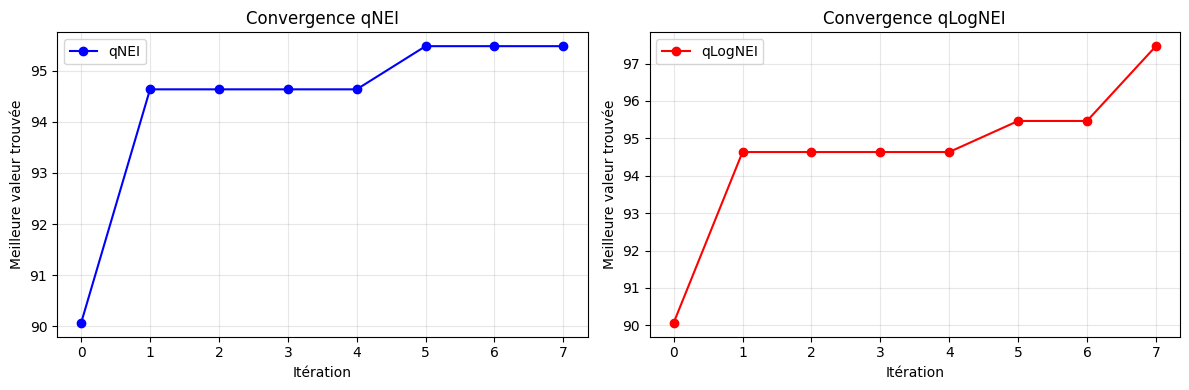

qNEI - Meilleure valeur: 95.480
qLogNEI - Meilleure valeur: 97.466
qNEI - Points explorés: 8
qLogNEI - Points explorés: 8


In [14]:
# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 512")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [46]:
# 4 Initial Point - Increasing MC_SAMPLES

MC_SAMPLES = 512 

x = np.linspace(0, 8, 4)
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []

iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_24792\2429387479.py:22: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return U*f1*f2 + np_rng.normal(size=f1.shape)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_24792\2429387479.py:22: DeprecationWarning: __array_wrap__ must accept context and retu

=== Comparaison des méthodes qNEI et qLogNEI ===


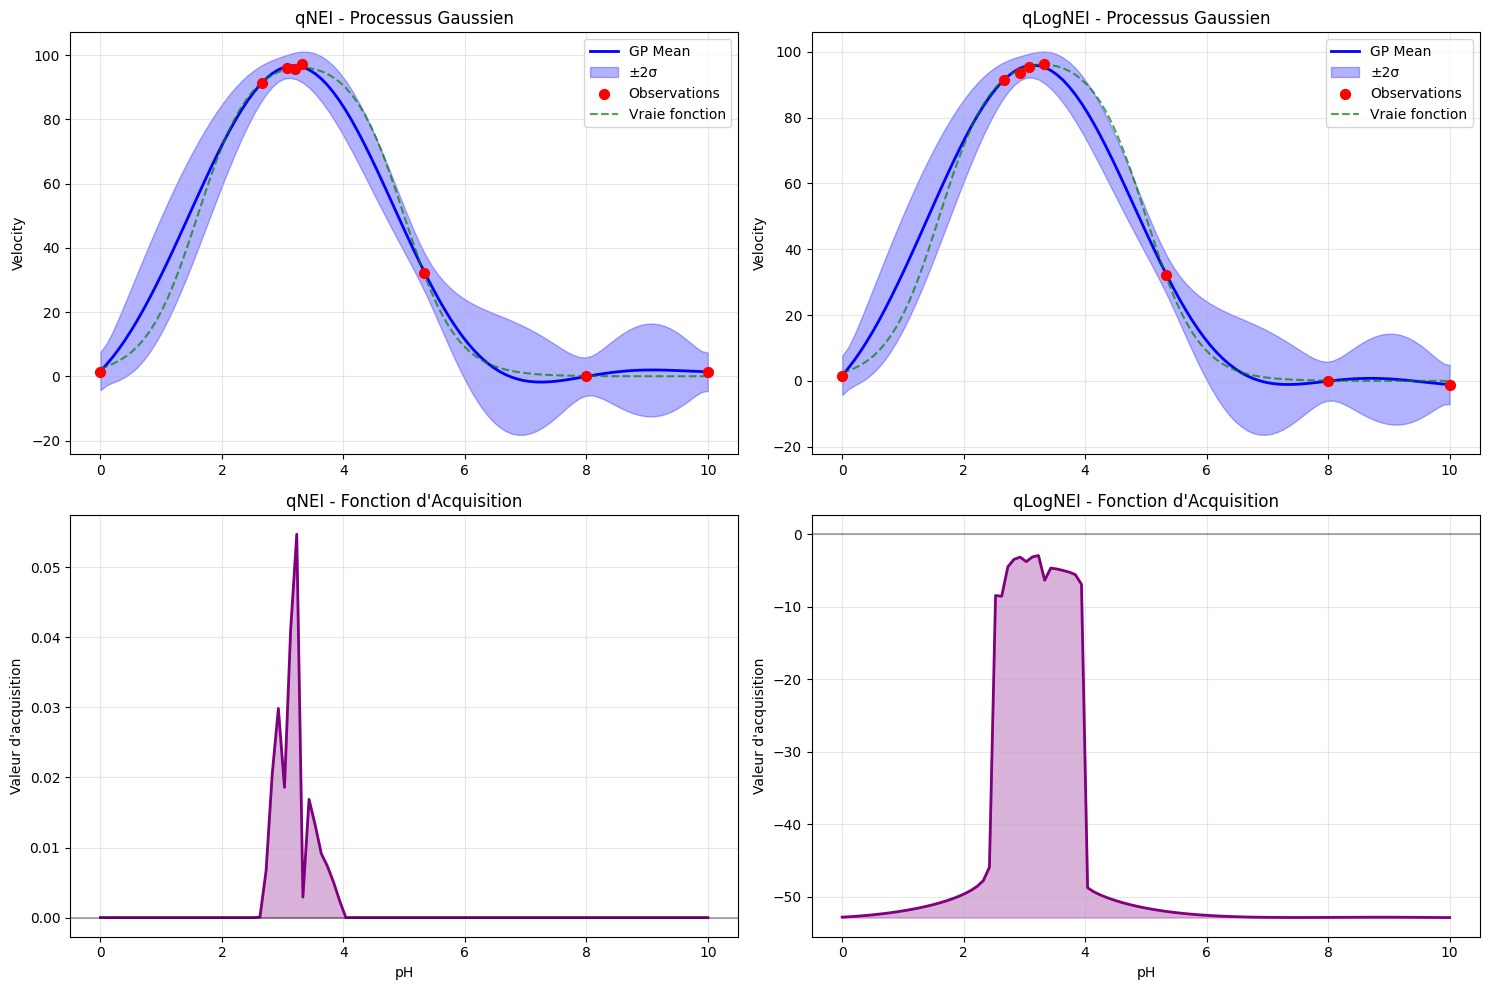

In [47]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

=== Analyse de la convergence === with MC_SAMPLES = 512


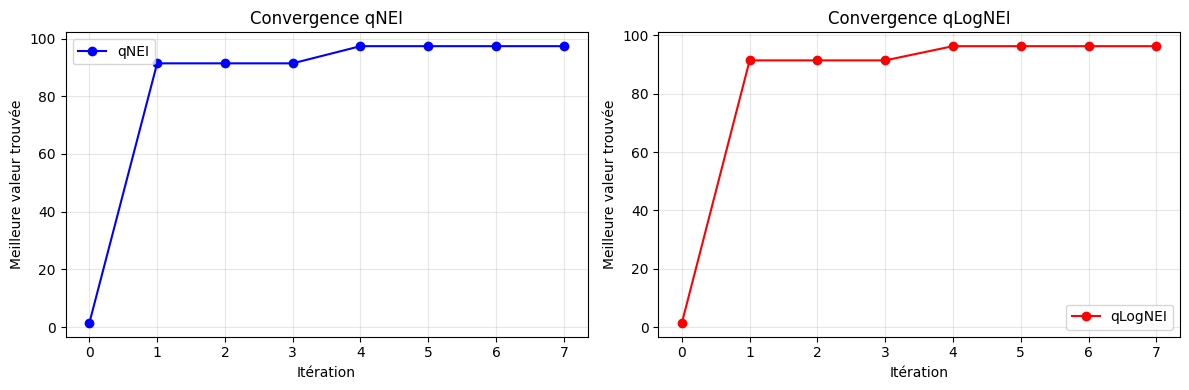

qNEI - Meilleure valeur: 97.354
qLogNEI - Meilleure valeur: 96.270
qNEI - Points explorés: 8
qLogNEI - Points explorés: 8


In [48]:
# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 512")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [ ]:
# 4 Initial Points (Increasing Research Space + Randomly chosen points)

MC_SAMPLES = 512 
np.random.seed(42)
unique_values = np.random.choice(range(0, 11), size=5, replace=False)
print(f"Valeurs uniques garanties: {unique_values}")
print()

x = np.linspace(0, 8, 4)
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 
iterations_data = []

iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': 0
})

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

    iterations_data.append({
        'train_x_nei': train_x_nei.clone(),
        'train_y_nei': y_obs_nei.clone(),
        'train_x_lognei': train_x_lognei.clone(),
        'train_y_lognei': y_obs_lognei.clone(),
        'iteration': trial
    })

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\linear_operator\utils\cholesky.py:40: NumericalWarning: A not p.d., added jitter of 1.0e-08 to the diagonal
  warnings.warn(
c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian

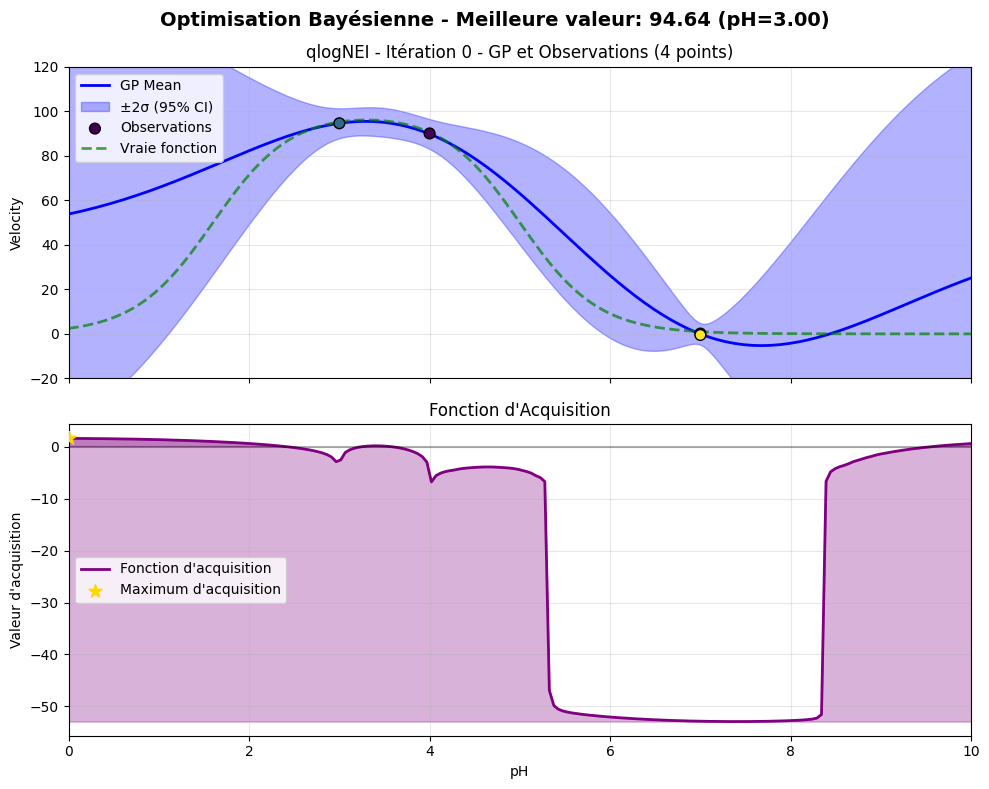

In [16]:
import matplotlib
import matplotlib.animation as animation

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
# Grille pour l'évaluation
x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 200).unsqueeze(-1)
x_true = np.linspace(bounds[0].item(), bounds[1].item(), 200)
y_true = fraction_active_true(x_true)
acquisition_type='qlogNEI'

def animate(frame):
    # Nettoyer les axes
    ax1.clear()
    ax2.clear()

    data = iterations_data[frame]
    if acquisition_type == 'qNEI':
        current_train_x = data['train_x_nei']
        current_train_y = data['train_y_nei']
    else: 
        current_train_x = data['train_x_lognei']
        current_train_y = data['train_y_lognei']

    iteration = data['iteration']
        
    # Reconstruire le modèle pour cette itération
    if len(current_train_x) >= 1:
        model, mll = initialize_model(current_train_x, current_train_y)
        fit_gpytorch_mll(mll)
            
        model.eval()
        with torch.no_grad():
            posterior = model.posterior(x_test)
            mean = posterior.mean.squeeze()
            std = torch.sqrt(posterior.variance.squeeze())
                
            # Fonction d'acquisition
            qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
            if acquisition_type == 'qNEI':
                acq_func = qNoisyExpectedImprovement(
                    model=model,
                    X_baseline=current_train_x,
                    sampler=qmc_sampler
                )
            else:
                acq_func = qLogNoisyExpectedImprovement(
                    model=model,
                    X_baseline=current_train_x,
                    sampler=qmc_sampler
                )
                
            acq_values = acq_func(x_test.unsqueeze(1)).squeeze()
            
        # Convertir en numpy
        x_np = x_test.squeeze().numpy()
        mean_np = mean.numpy()
        std_np = std.numpy()
        acq_np = acq_values.numpy()
    else:
        # Cas initial : pas assez de points pour un GP
        x_np = x_test.squeeze().numpy()
        mean_np = np.zeros_like(x_np)
        std_np = np.ones_like(x_np) * 10  # Incertitude élevée
        acq_np = np.ones_like(x_np)  # Acquisition uniforme
        
    train_x_np = current_train_x.squeeze().numpy()
    train_y_np = current_train_y.squeeze().numpy()
    
    # Graphique 1: GP et observations
    if len(current_train_x) >= 1:
        ax1.plot(x_np, mean_np, 'b-', label='GP Mean', linewidth=2)
        ax1.fill_between(x_np, mean_np - 2*std_np, mean_np + 2*std_np,
                        alpha=0.3, color='blue', label='±2σ (95% CI)')
        
    # Points d'observation avec couleurs selon l'ordre
    try :
        colors = plt.cm.viridis(np.linspace(0, 1, len(train_x_np)))
    except TypeError:
        colors = plt.cm.viridis(np.linspace(0, 1, train_x_np.size))
    scatter = ax1.scatter(train_x_np, train_y_np, c=colors, s=60, 
                        zorder=5, label='Observations', edgecolors='black', linewidth=1)
        
    # Marquer le dernier point ajouté
    if iteration > 0:
        ax1.scatter(train_x_np[-1], train_y_np[-1], c='red', s=100, 
                    marker='*', zorder=6, label='Nouveau point', edgecolors='black')
        
    # Vraie fonction
    ax1.plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction', linewidth=2)
        
    # Configuration
    ax1.set_ylabel('Velocity')
    try:
        ax1.set_title(f'{acquisition_type} - Itération {iteration} - GP et Observations ({len(train_x_np)} points)')
    except TypeError:
        ax1.set_title(f'{acquisition_type} - Itération {iteration} - GP et Observations ({train_x_np.size} points)')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(-20, 120)
        
    # Graphique 2: Fonction d'acquisition
    if len(current_train_x) >= 1:
        ax2.plot(x_np, acq_np, 'purple', linewidth=2, label='Fonction d\'acquisition')
        ax2.fill_between(x_np, 0, acq_np, where=(acq_np >= 0), 
                           alpha=0.3, color='purple', interpolate=True)
        if np.any(acq_np < 0):
            ax2.fill_between(x_np, acq_np.min(), acq_np, 
                               alpha=0.3, color='purple', interpolate=True)
        ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            
        # Marquer le maximum de la fonction d'acquisition
        max_idx = np.argmax(acq_np)
        if len(current_train_x) > 1:
            ax2.scatter(x_np[max_idx], acq_np[max_idx], c='gold', s=100, 
                        marker='*', zorder=6, label='Maximum d\'acquisition')
        
    ax2.set_xlabel('pH')
    ax2.set_ylabel('Valeur d\'acquisition')
    ax2.set_title('Fonction d\'Acquisition')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(bounds[0].item(), bounds[1].item())
        
    # Statistiques
    try : 
        n_output = len(train_y_np)
    except TypeError:
        n_output = train_y_np.size
    if n_output > 0:
        best_value = np.max(train_y_np)
        try : 
            best_x = train_x_np[np.argmax(train_y_np)]
        except IndexError:
            best_x = train_x_np
        fig.suptitle(f'Optimisation Bayésienne - Meilleure valeur: {best_value:.2f} (pH={best_x:.2f})', 
                        fontsize=14, fontweight='bold')
        
    plt.tight_layout()
    
    # Créer l'animation
anim = animation.FuncAnimation(
    fig, animate, frames=len(iterations_data), 
    interval=1500, repeat=True, blit=False
    )

writergif = animation.PillowWriter(fps=1000/1500)
anim.save('model_qLogNEI_4_init_points_random.gif', writer=writergif)

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML
import io
import base64

def animate_bayesian_optimization(
    objective_func,
    bounds,
    n_initial=2,
    n_iterations=10,
    acquisition_type='qNEI',
    figsize=(12, 8),
    interval=1500,
    save_gif=False,
    gif_filename='bayesian_opt_animation.gif'
):
    """
    Crée une animation de l'évolution du processus gaussien pendant l'optimisation bayésienne
    
    Args:
        objective_func: fonction objectif à optimiser
        bounds: limites de l'espace de recherche [tensor([[min], [max]])]
        n_initial: nombre de points d'initialisation
        n_iterations: nombre d'itérations d'optimisation
        acquisition_type: type de fonction d'acquisition ('qNEI' ou 'qLogNEI')
        figsize: taille de la figure
        interval: délai entre les frames (ms)
        save_gif: sauvegarder l'animation en GIF
        gif_filename: nom du fichier GIF
    
    Returns:
        animation matplotlib
    """
    
    # Initialisation des données
    x_init = torch.linspace(bounds[0].item(), bounds[1].item(), n_initial).unsqueeze(-1)
    y_init = objective_func(x_init.squeeze()).unsqueeze(-1)
    
    # Grille pour l'évaluation
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 200).unsqueeze(-1)
    x_true = np.linspace(bounds[0].item(), bounds[1].item(), 200)
    y_true = fraction_active_true(x_true)
    
    # Stockage des données pour chaque itération
    iterations_data = []
    
    # Points d'entraînement actuels
    train_x = x_init.clone()
    train_y = y_init.clone()
    
    # Stocker l'état initial
    iterations_data.append({
        'train_x': train_x.clone(),
        'train_y': train_y.clone(),
        'iteration': 0
    })
    
    # Effectuer les itérations d'optimisation
    for i in range(n_iterations):
        # Initialiser et entraîner le modèle
        model, mll = initialize_model(train_x, train_y)
        fit_gpytorch_mll(mll)
        
        # Créer la fonction d'acquisition
        qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
        
        if acquisition_type == 'qNEI':
            acq_func = qNoisyExpectedImprovement(
                model=model,
                X_baseline=train_x,
                sampler=qmc_sampler
            )
        else:  # qLogNEI
            acq_func = qLogNoisyExpectedImprovement(
                model=model,
                X_baseline=train_x,
                sampler=qmc_sampler
            )
        
        # Optimiser la fonction d'acquisition
        new_x, new_y = optimize_acqf_and_get_observation(acq_func, bounds)
        
        # Mettre à jour les données d'entraînement
        train_x = torch.cat([train_x, new_x])
        train_y = torch.cat([train_y, new_y])
        
        # Stocker les données de cette itération
        iterations_data.append({
            'train_x': train_x.clone(),
            'train_y': train_y.clone(),
            'iteration': i + 1
        })
    
    # Créer l'animation
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    def animate(frame):
        # Nettoyer les axes
        ax1.clear()
        ax2.clear()
        
        data = iterations_data[frame]
        current_train_x = data['train_x']
        current_train_y = data['train_y']
        iteration = data['iteration']
        
        # Reconstruire le modèle pour cette itération
        if len(current_train_x) > 1:
            model, mll = initialize_model(current_train_x, current_train_y)
            fit_gpytorch_mll(mll)
            
            model.eval()
            with torch.no_grad():
                posterior = model.posterior(x_test)
                mean = posterior.mean.squeeze()
                std = torch.sqrt(posterior.variance.squeeze())
                
                # Fonction d'acquisition
                qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
                if acquisition_type == 'qNEI':
                    acq_func = qNoisyExpectedImprovement(
                        model=model,
                        X_baseline=current_train_x,
                        sampler=qmc_sampler
                    )
                else:
                    acq_func = qLogNoisyExpectedImprovement(
                        model=model,
                        X_baseline=current_train_x,
                        sampler=qmc_sampler
                    )
                
                acq_values = acq_func(x_test.unsqueeze(1)).squeeze()
            
            # Convertir en numpy
            x_np = x_test.squeeze().numpy()
            mean_np = mean.numpy()
            std_np = std.numpy()
            acq_np = acq_values.numpy()
        else:
            # Cas initial : pas assez de points pour un GP
            x_np = x_test.squeeze().numpy()
            mean_np = np.zeros_like(x_np)
            std_np = np.ones_like(x_np) * 10  # Incertitude élevée
            acq_np = np.ones_like(x_np)  # Acquisition uniforme
        
        train_x_np = current_train_x.squeeze().numpy()
        train_y_np = current_train_y.squeeze().numpy()
        
        # Graphique 1: GP et observations
        if len(current_train_x) > 1:
            ax1.plot(x_np, mean_np, 'b-', label='GP Mean', linewidth=2)
            ax1.fill_between(x_np, mean_np - 2*std_np, mean_np + 2*std_np,
                           alpha=0.3, color='blue', label='±2σ (95% CI)')
        
        # Points d'observation avec couleurs selon l'ordre
        colors = plt.cm.viridis(np.linspace(0, 1, len(train_x_np)))
        scatter = ax1.scatter(train_x_np, train_y_np, c=colors, s=60, 
                            zorder=5, label='Observations', edgecolors='black', linewidth=1)
        
        # Marquer le dernier point ajouté
        if iteration > 0:
            ax1.scatter(train_x_np[-1], train_y_np[-1], c='red', s=100, 
                       marker='*', zorder=6, label='Nouveau point', edgecolors='black')
        
        # Vraie fonction
        ax1.plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction', linewidth=2)
        
        # Configuration
        ax1.set_ylabel('Velocity')
        ax1.set_title(f'{acquisition_type} - Itération {iteration} - GP et Observations ({len(train_x_np)} points)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(-20, 120)
        
        # Graphique 2: Fonction d'acquisition
        if len(current_train_x) > 1:
            ax2.plot(x_np, acq_np, 'purple', linewidth=2, label='Fonction d\'acquisition')
            ax2.fill_between(x_np, 0, acq_np, where=(acq_np >= 0), 
                           alpha=0.3, color='purple', interpolate=True)
            if np.any(acq_np < 0):
                ax2.fill_between(x_np, acq_np.min(), acq_np, where=(acq_np < 0), 
                               alpha=0.3, color='red', interpolate=True)
            ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            
            # Marquer le maximum de la fonction d'acquisition
            max_idx = np.argmax(acq_np)
            ax2.scatter(x_np[max_idx], acq_np[max_idx], c='gold', s=100, 
                       marker='*', zorder=6, label='Maximum d\'acquisition')
        
        ax2.set_xlabel('pH')
        ax2.set_ylabel('Valeur d\'acquisition')
        ax2.set_title('Fonction d\'Acquisition')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(bounds[0].item(), bounds[1].item())
        
        # Statistiques
        if len(train_y_np) > 0:
            best_value = np.max(train_y_np)
            best_x = train_x_np[np.argmax(train_y_np)]
            fig.suptitle(f'Optimisation Bayésienne - Meilleure valeur: {best_value:.2f} (pH={best_x:.2f})', 
                        fontsize=14, fontweight='bold')
        
        plt.tight_layout()
    
    # Créer l'animation
    anim = animation.FuncAnimation(
        fig, animate, frames=len(iterations_data), 
        interval=interval, repeat=True, blit=False
    )
    
    # Sauvegarder en GIF si demandé
    if save_gif:
        print(f"💾 Sauvegarde de l'animation en {gif_filename}...")
        writergif = animation.PillowWriter(fps=1000/interval)
        anim.save(gif_filename, writer=writergif)
        print(f"✅ Animation sauvegardée: {gif_filename}")
    
    return anim

print("✅ Fonction d'animation créée avec succès!")

- *Visualisation des résultats de l'optimisation bayésienne*

In [4]:
def fraction_active_true(x, pK = [1.6, 5.0], U=100):

    f1 = 1./(1 + 10**(pK[0]-x))
    f2 = 1./(1 + 10**(x-pK[1]))
    
    return U*f1*f2

pH = np.linspace(0.5, 8.0, 50)
y_true = fraction_active_true(pH)

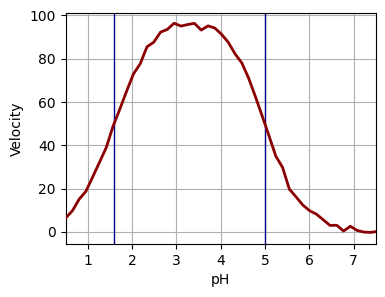

In [ ]:
y_true = fraction_active_true(pH)
pH = np.linspace(0.5, 8.0, 50)
pK = [1.6, 5.0]

fig, ax = plt.subplots(figsize=(4,3))
#ax.scatter(pH, fraction_active(pH), s=10, color='darkred', zorder=5)
ax.plot(pH, fraction_active(pH), color='darkred', lw=2, zorder=5)
ax.set_xlabel('pH')
ax.set_ylabel('Velocity')
ax.set_xlim(0.5, 7.5)
ax.grid(True)
ax.axvline(pK[0], 0, 100, color='darkblue', lw=1)
ax.axvline(pK[1], 0, 100, color='darkblue', lw=1)
plt.show()

In [6]:
def plot_gp_and_acquisition(model, acquisition_func, bounds, train_x, train_y, title="GP et Fonction d'Acquisition"):
    """
    Visualise le modèle GP, l'incertitude et la fonction d'acquisition
    
    Args:
        model: modèle GP BoTorch
        acquisition_func: fonction d'acquisition
        bounds: limites de l'espace de recherche
        train_x: points d'entraînement (input)
        train_y: points d'entraînement (output)
        title: titre du graphique
    """
    # Créer une grille de points pour l'évaluation
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 100).unsqueeze(-1)
    
    # Mettre le modèle en mode évaluation
    model.eval()
    
    with torch.no_grad():
        # Prédictions du GP
        posterior = model.posterior(x_test)
        mean = posterior.mean.squeeze()
        variance = posterior.variance.squeeze()
        std = torch.sqrt(variance)
        
        # Calculer la fonction d'acquisition
        acq_values = acquisition_func(x_test.unsqueeze(1))
    
    # Convertir en numpy pour matplotlib
    x_np = x_test.squeeze().numpy()
    mean_np = mean.numpy()
    std_np = std.numpy()
    train_x_np = train_x.squeeze().numpy()
    train_y_np = train_y.squeeze().numpy()
    acq_np = acq_values.squeeze().numpy()
    
    # Créer le graphique avec deux sous-graphiques
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Graphique 1: GP mean et incertitude
    ax1.plot(x_np, mean_np, 'b-', label='GP Mean', linewidth=2)
    ax1.fill_between(x_np, mean_np - 2*std_np, mean_np + 2*std_np, 
                     alpha=0.3, color='blue', label='±2σ (95% CI)')
    ax1.scatter(train_x_np, train_y_np, c='red', s=50, zorder=5, label='Observations')
    
    # Ajouter la vraie fonction si disponible
    x_true = np.linspace(bounds[0].item(), bounds[1].item(), 100)
    y_true = fraction_active_true(x_true)
    ax1.plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction', linewidth=2)
    
    ax1.set_ylabel('Velocity')
    ax1.set_title(f'{title} - Processus Gaussien')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Graphique 2: Fonction d'acquisition
    ax2.plot(x_np, acq_np, 'purple', linewidth=2, label='Fonction d\'acquisition')
    
    # Gérer le remplissage pour les valeurs négatives et positives
    ax2.fill_between(x_np, 0, acq_np, where=(acq_np >= 0), alpha=0.3, color='purple', interpolate=True)
    ax2.fill_between(x_np, acq_np.min(), acq_np, where=(acq_np <= 0), alpha=0.3, color='purple', interpolate=True)
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    
    ax2.set_xlabel('pH')
    ax2.set_ylabel('Valeur d\'acquisition')
    ax2.set_title('Fonction d\'Acquisition')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    #return fig

In [ ]:
# Try to see how the initialization change the BO performance 
# Animate the graphics 

=== Visualisation qNEI ===


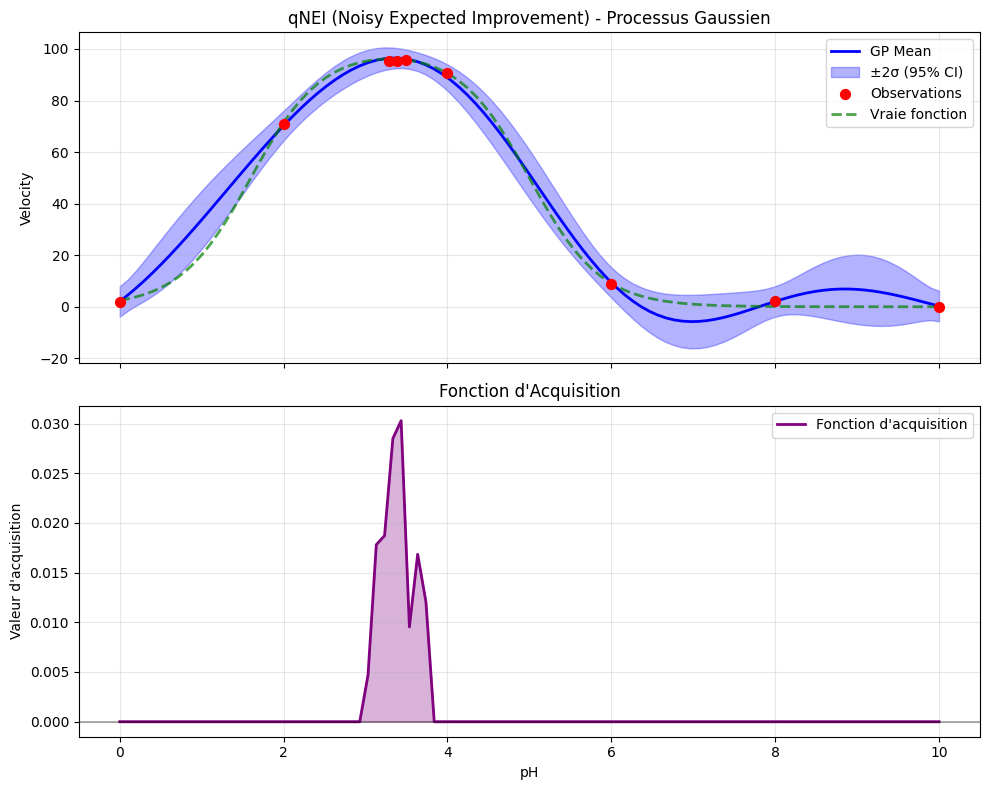

In [87]:
# Visualiser les résultats pour qNEI (Noisy Expected Improvement)
print("=== Visualisation qNEI ===")
plot_gp_and_acquisition(model_nei, qNEI, bounds, train_x_nei, y_obs_nei, 
                        title="qNEI (Noisy Expected Improvement)")

=== Visualisation qLogNEI ===


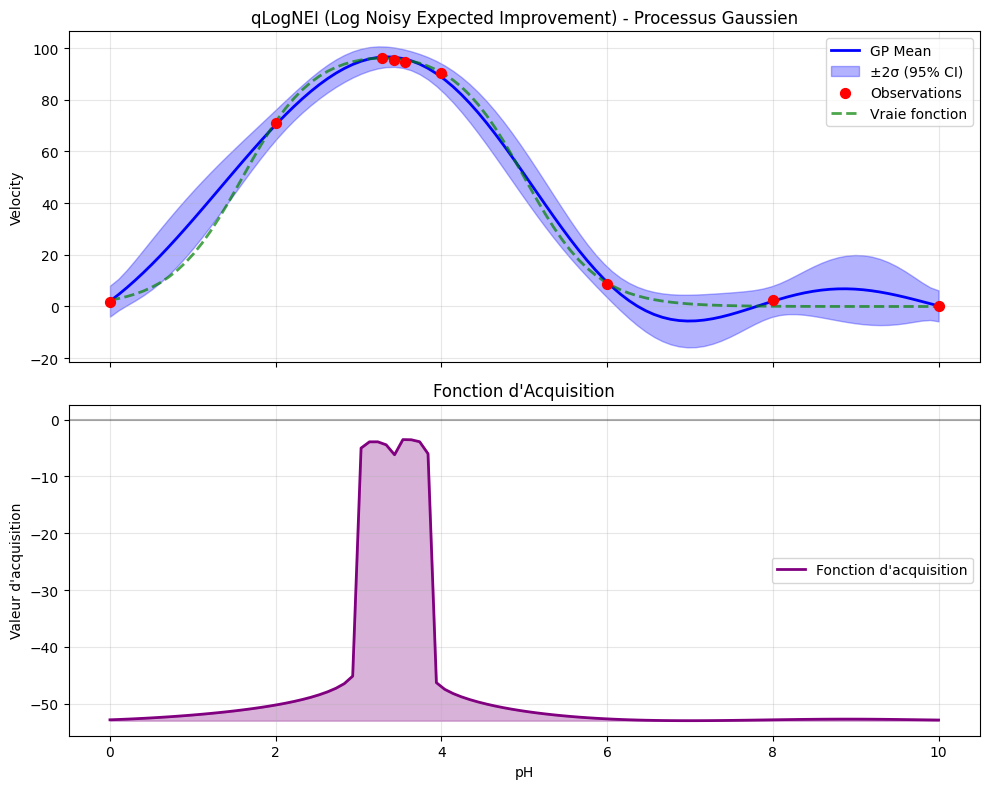

In [86]:
# Visualiser les résultats pour qLogNEI (Log Noisy Expected Improvement)
print("=== Visualisation qLogNEI ===")
plot_gp_and_acquisition(model_lognei, qlogNEI, bounds, train_x_lognei, y_obs_lognei, 
                        title="qLogNEI (Log Noisy Expected Improvement)")

In [ ]:
# Analyser la convergence des points d'observation
def plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei):
    """
    Visualise la convergence des deux méthodes d'optimisation
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # qNEI convergence
    iterations = range(len(train_x_nei))
    max_values_nei = [y_obs_nei[:i+1].max().item() for i in iterations]
    
    ax1.plot(iterations, max_values_nei, 'bo-', label='qNEI')
    ax1.set_xlabel('Itération')
    ax1.set_ylabel('Meilleure valeur trouvée')
    ax1.set_title('Convergence qNEI')
    ax1.grid(True, alpha=0.3)
    ax1.legend()
    
    # qLogNEI convergence
    iterations_log = range(len(train_x_lognei))
    max_values_lognei = [y_obs_lognei[:i+1].max().item() for i in iterations_log]
    
    ax2.plot(iterations_log, max_values_lognei, 'ro-', label='qLogNEI')
    ax2.set_xlabel('Itération')
    ax2.set_ylabel('Meilleure valeur trouvée')
    ax2.set_title('Convergence qLogNEI')
    ax2.grid(True, alpha=0.3)
    ax2.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les statistiques
    print(f"qNEI - Meilleure valeur: {max(max_values_nei):.3f}")
    print(f"qLogNEI - Meilleure valeur: {max(max_values_lognei):.3f}")
    print(f"qNEI - Points explorés: {len(train_x_nei)}")
    print(f"qLogNEI - Points explorés: {len(train_x_lognei)}")
    
    #return fig

# Analyser la convergence
print("=== Analyse de la convergence ===")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [11]:
# Fonction pour comparer les deux méthodes côte à côte
def compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
                   train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei):
    """
    Compare les deux méthodes d'optimisation bayésienne côte à côte
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Créer une grille de points pour l'évaluation
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 100).unsqueeze(-1)
    
    # Évaluer les modèles
    model_nei.eval()
    model_lognei.eval()
    
    with torch.no_grad():
        # Prédictions qNEI
        posterior_nei = model_nei.posterior(x_test)
        mean_nei = posterior_nei.mean.squeeze()
        std_nei = torch.sqrt(posterior_nei.variance.squeeze())
        acq_nei = qNEI(x_test.unsqueeze(1)).squeeze()
        
        # Prédictions qLogNEI
        posterior_lognei = model_lognei.posterior(x_test)
        mean_lognei = posterior_lognei.mean.squeeze()
        std_lognei = torch.sqrt(posterior_lognei.variance.squeeze())
        acq_lognei = qlogNEI(x_test.unsqueeze(1)).squeeze()
    
    # Convertir en numpy
    x_np = x_test.squeeze().numpy()
    x_true = np.linspace(bounds[0].item(), bounds[1].item(), 100)
    y_true = fraction_active_true(x_true)
    
    # Graphique 1: GP qNEI
    axes[0,0].plot(x_np, mean_nei.numpy(), 'b-', label='GP Mean', linewidth=2)
    axes[0,0].fill_between(x_np, (mean_nei - 2*std_nei).numpy(), (mean_nei + 2*std_nei).numpy(), 
                          alpha=0.3, color='blue', label='±2σ')
    axes[0,0].scatter(train_x_nei.squeeze().numpy(), y_obs_nei.squeeze().numpy(), 
                     c='red', s=50, zorder=5, label='Observations')
    axes[0,0].plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction')
    axes[0,0].set_title('qNEI - Processus Gaussien')
    axes[0,0].set_ylabel('Velocity')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # Graphique 2: GP qLogNEI
    axes[0,1].plot(x_np, mean_lognei.numpy(), 'b-', label='GP Mean', linewidth=2)
    axes[0,1].fill_between(x_np, (mean_lognei - 2*std_lognei).numpy(), (mean_lognei + 2*std_lognei).numpy(), 
                          alpha=0.3, color='blue', label='±2σ')
    axes[0,1].scatter(train_x_lognei.squeeze().numpy(), y_obs_lognei.squeeze().numpy(), 
                     c='red', s=50, zorder=5, label='Observations')
    axes[0,1].plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction')
    axes[0,1].set_title('qLogNEI - Processus Gaussien')
    axes[0,1].set_ylabel('Velocity')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # Graphique 3: Acquisition qNEI
    axes[1,0].plot(x_np, acq_nei.numpy(), 'purple', linewidth=2)
    acq_nei_np = acq_nei.numpy()
    axes[1,0].fill_between(x_np, 0, acq_nei_np, where=(acq_nei_np >= 0), alpha=0.3, color='purple', interpolate=True)
    axes[1,0].fill_between(x_np, 0, acq_nei_np, where=(acq_nei_np < 0), alpha=0.3, color='red', interpolate=True)
    axes[1,0].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1,0].set_title('qNEI - Fonction d\'Acquisition')
    axes[1,0].set_xlabel('pH')
    axes[1,0].set_ylabel('Valeur d\'acquisition')
    axes[1,0].grid(True, alpha=0.3)
    
    # Graphique 4: Acquisition qLogNEI
    axes[1,1].plot(x_np, acq_lognei.numpy(), 'purple', linewidth=2)
    acq_lognei_np = acq_lognei.numpy()
    axes[1,1].fill_between(x_np, 0, acq_lognei_np, where=(acq_lognei_np >= 0), alpha=0.3, color='purple', interpolate=True)
    axes[1,1].fill_between(x_np, acq_lognei_np.min(), acq_lognei_np, where=(acq_lognei_np < 0), alpha=0.3, color='purple', interpolate=True)
    axes[1,1].axhline(y=0, color='black', linestyle='-', alpha=0.3)
    axes[1,1].set_title('qLogNEI - Fonction d\'Acquisition')
    axes[1,1].set_xlabel('pH')
    axes[1,1].set_ylabel('Valeur d\'acquisition')
    axes[1,1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

=== Comparaison des méthodes qNEI et qLogNEI ===


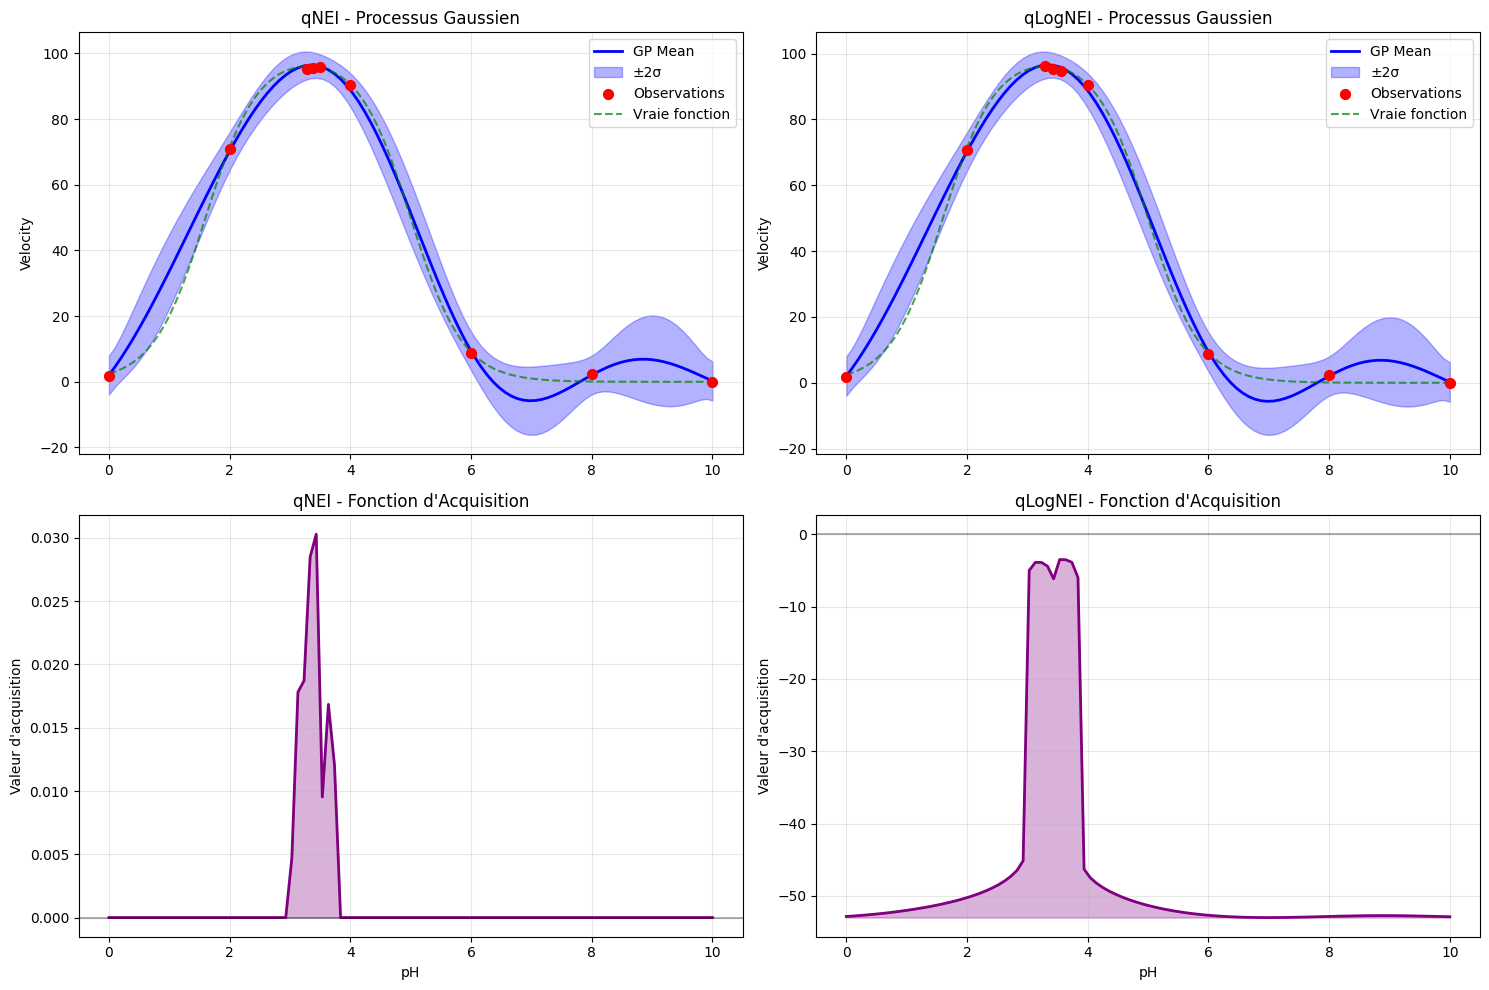

In [95]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [ ]:
# Analyser les valeurs des fonctions d'acquisition
def analyze_acquisition_functions(model_nei, model_lognei, qNEI, qlogNEI, bounds):
    """
    Analyse les propriétés des fonctions d'acquisition
    """
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 100).unsqueeze(-1)
    
    model_nei.eval()
    model_lognei.eval()
    
    with torch.no_grad():
        acq_nei = qNEI(x_test.unsqueeze(1)).squeeze()
        acq_lognei = qlogNEI(x_test.unsqueeze(1)).squeeze()
    
    print("=== Analyse des fonctions d'acquisition ===")
    print(f"qNEI:")
    print(f"  - Min: {acq_nei.min().item():.6f}")
    print(f"  - Max: {acq_nei.max().item():.6f}")
    print(f"  - Moyenne: {acq_nei.mean().item():.6f}")
    print(f"  - Valeurs négatives: {(acq_nei < 0).sum().item()}/{len(acq_nei)}")
    
    print(f"\nqLogNEI:")
    print(f"  - Min: {acq_lognei.min().item():.6f}")
    print(f"  - Max: {acq_lognei.max().item():.6f}")
    print(f"  - Moyenne: {acq_lognei.mean().item():.6f}")
    print(f"  - Valeurs négatives: {(acq_lognei < 0).sum().item()}/{len(acq_lognei)}")
    
    # Trouver les maxima
    argmax_nei = x_test[acq_nei.argmax()].item()
    argmax_lognei = x_test[acq_lognei.argmax()].item()
    
    print(f"\nProchain point suggéré:")
    print(f"  - qNEI: pH = {argmax_nei:.3f} (valeur = {acq_nei.max().item():.6f})")
    print(f"  - qLogNEI: pH = {argmax_lognei:.3f} (valeur = {acq_lognei.max().item():.6f})")


# Analyser les fonctions d'acquisition
analyze_acquisition_functions(model_nei, model_lognei, qNEI, qlogNEI, bounds)

=== Analyse des fonctions d'acquisition ===
qNEI:
  - Min: 0.000000
  - Max: 0.030296
  - Moyenne: 0.001385
  - Valeurs négatives: 0/100

qLogNEI:
  - Min: -52.997760
  - Max: -3.500539
  - Moyenne: -47.398620
  - Valeurs négatives: 100/100

Prochain point suggéré:
  - qNEI: pH = 3.434 (valeur = 0.030296)
  - qLogNEI: pH = 3.535 (valeur = -3.500539)


=== Analyse de la convergence === with MC_SAMPLES = 500


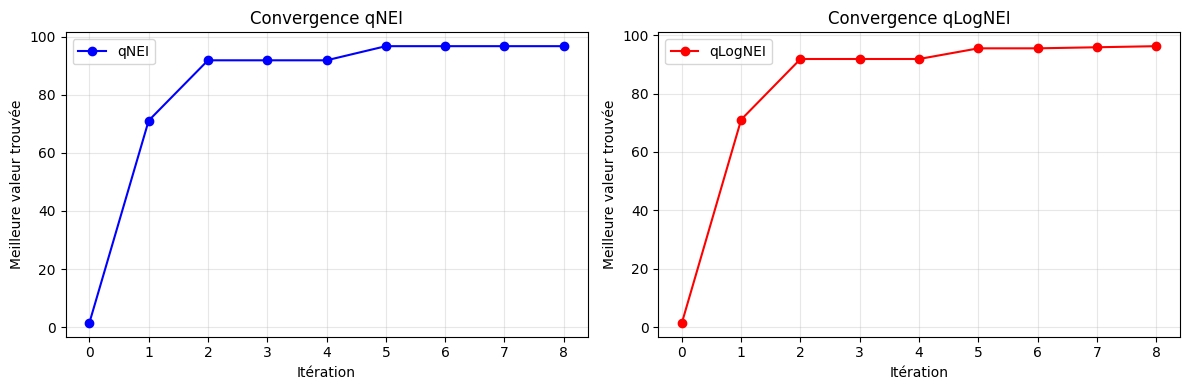

qNEI - Meilleure valeur: 96.703
qLogNEI - Meilleure valeur: 96.229
qNEI - Points explorés: 9
qLogNEI - Points explorés: 9


In [23]:
# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 500")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

2 Starting Points 

In [ ]:
bounds = torch.tensor([[0.], [10.]], dtype=float)

NUM_RESTARTS = 10
BATCH_SIZE = 1
MC_SAMPLES = 32
RAW_SAMPLES = 32

x = np.linspace(0, 8, 2)
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei, n_input=1, n_output=1, fixed=False)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei, n_input=1, n_output=1, fixed=False)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_15256\649664219.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return U*f1*f2 + np_rng.normal(size=f1.shape)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_15256\649664219.py:8: DeprecationWarning: __array_wrap__ must accept context and return_s

=== Comparaison des méthodes qNEI et qLogNEI ===


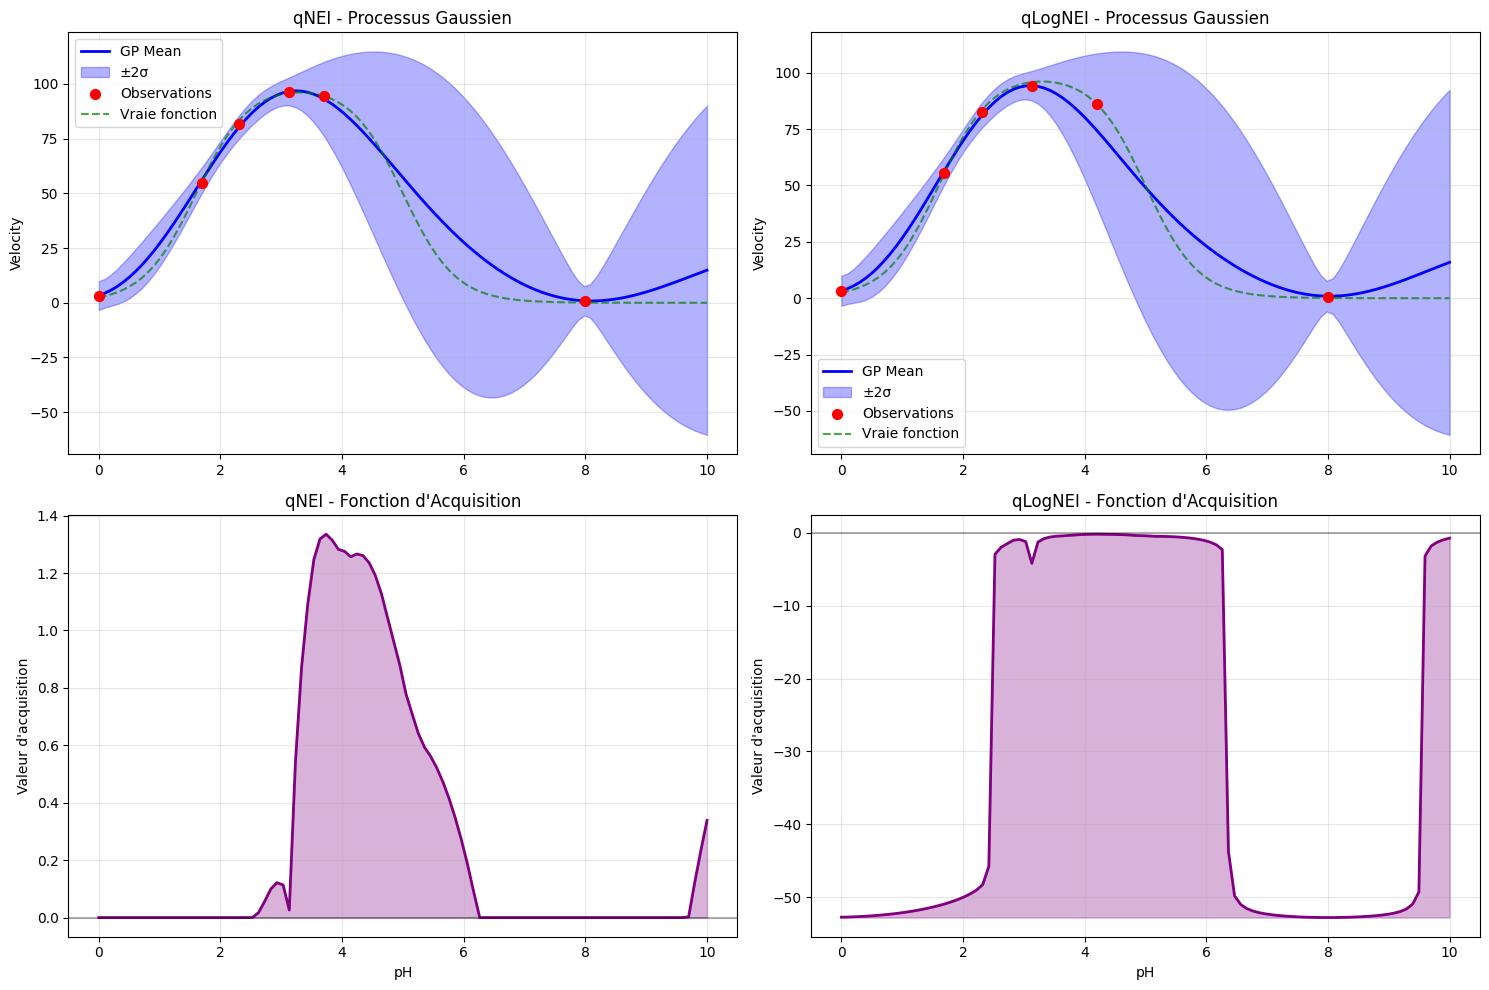

=== Analyse de la convergence === with MC_SAMPLES = 500


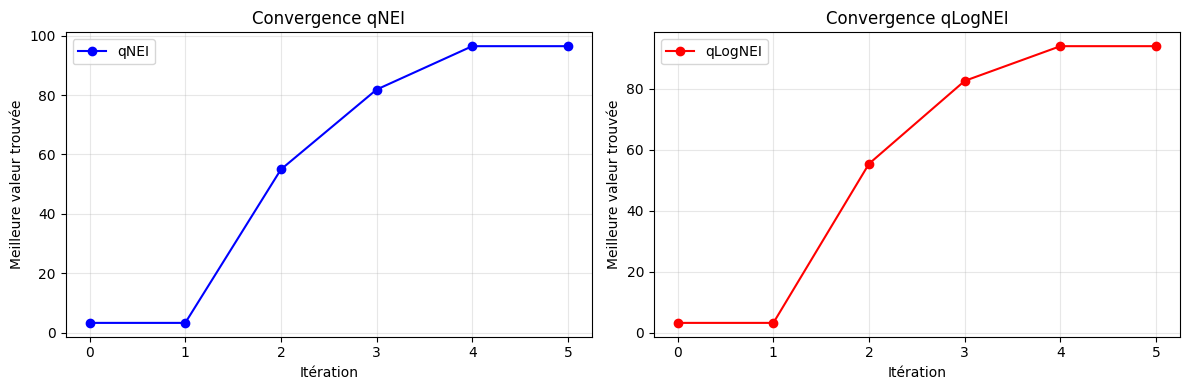

qNEI - Meilleure valeur: 96.478
qLogNEI - Meilleure valeur: 94.050
qNEI - Points explorés: 6
qLogNEI - Points explorés: 6


In [60]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 500")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [14]:
bounds = torch.tensor([[0.], [10.]], dtype=float)

NUM_RESTARTS = 10
BATCH_SIZE = 1
MC_SAMPLES = 500
RAW_SAMPLES = 32

x = np.linspace(0, 8, 2)
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_37528\649664219.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return U*f1*f2 + np_rng.normal(size=f1.shape)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_37528\649664219.py:8: DeprecationWarning: __array_wrap__ must accept context and return_s

=== Comparaison des méthodes qNEI et qLogNEI ===


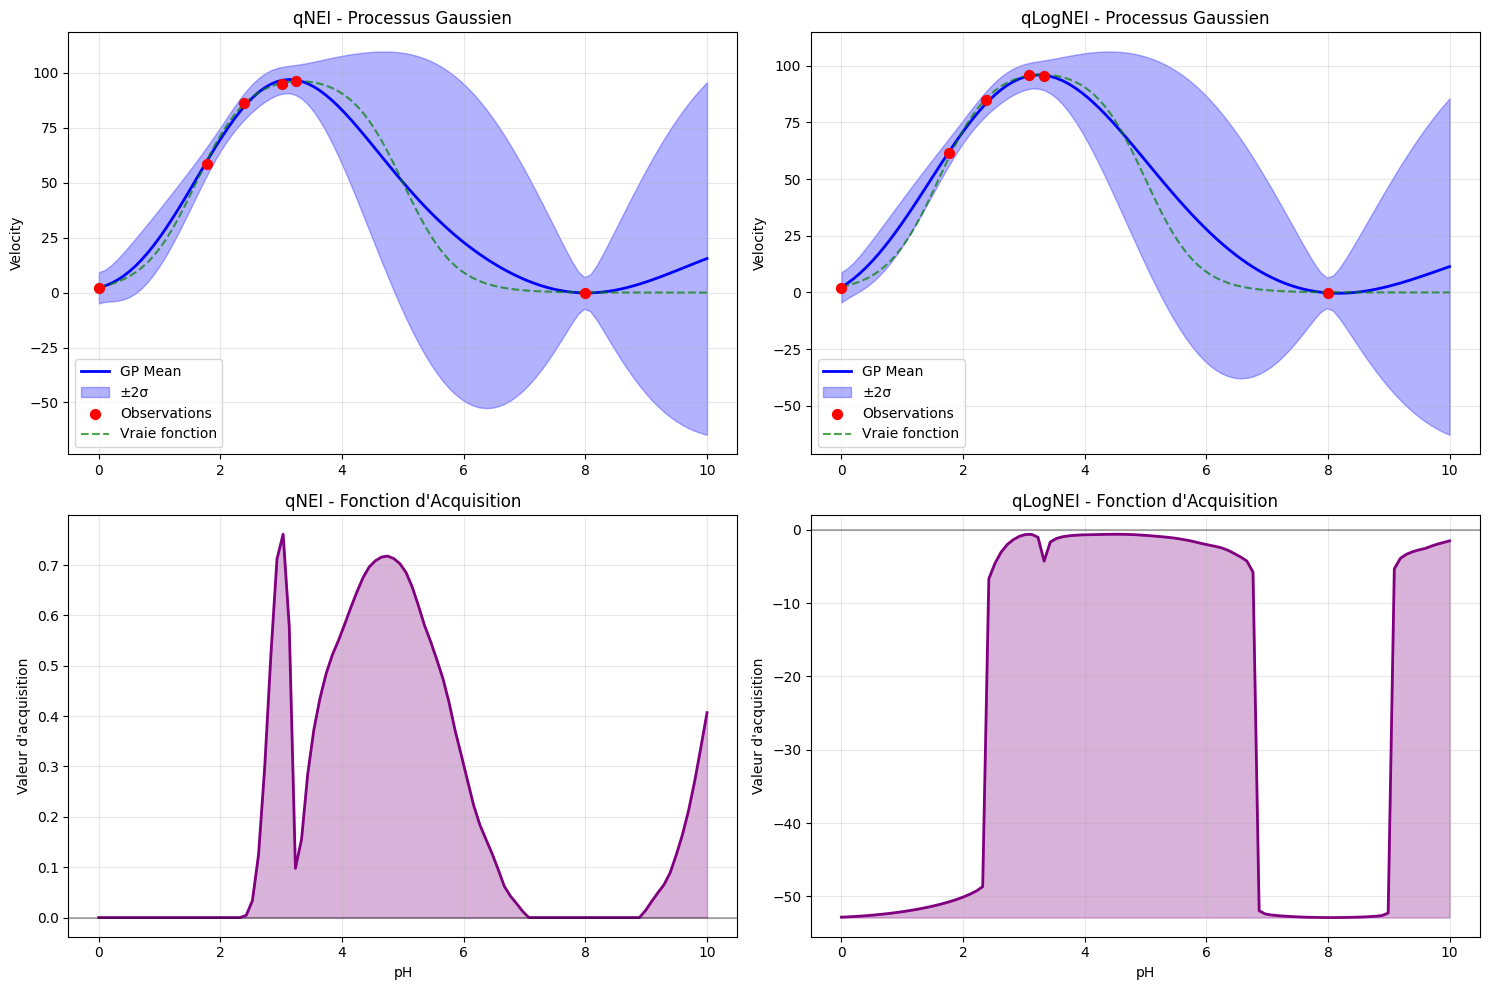

=== Analyse de la convergence === with MC_SAMPLES = 500


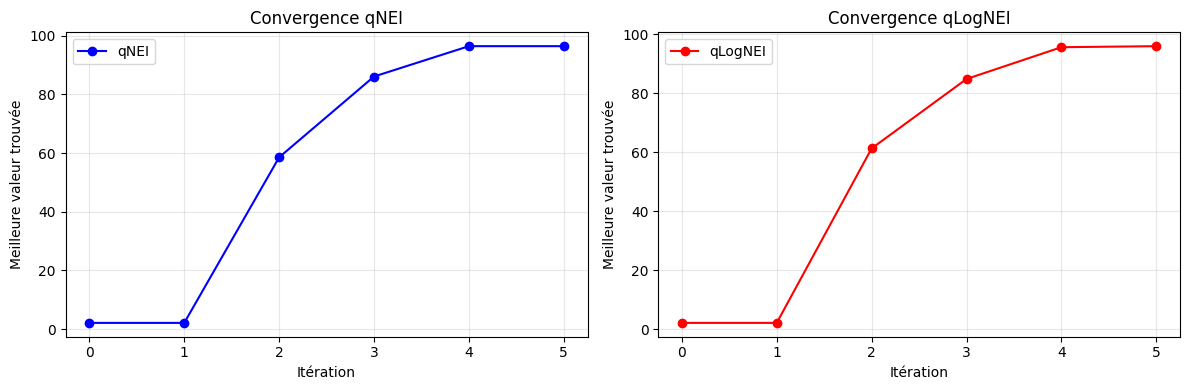

qNEI - Meilleure valeur: 96.396
qLogNEI - Meilleure valeur: 96.030
qNEI - Points explorés: 6
qLogNEI - Points explorés: 6


In [15]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 500")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

In [30]:
x.dtype = 'float32'

In [38]:
x = np.random.randint(low=0, high=11, size=(1,))
x[0] = float(x[0])
type(x)

numpy.ndarray

In [32]:
bounds = torch.tensor([[0.], [10.]], dtype=float)

NUM_RESTARTS = 10
BATCH_SIZE = 1
MC_SAMPLES = 500
RAW_SAMPLES = 32

x = np.random.randint(low=0, high=11, size=(2,))
x.dtype = 'float64'
y = fraction_active(x)
train_x_nei= torch.tensor(x.reshape(-1,1))
y_obs_nei = torch.tensor(y.reshape(-1,1))
train_x_lognei= torch.tensor(x.reshape(-1,1))
y_obs_lognei = torch.tensor(y.reshape(-1,1))
N_Trial = 4 

for trial in range(1, N_Trial+1):

    model_nei, mll_nei = initialize_model(train_x_nei, y_obs_nei)
    model_lognei, mll_lognei = initialize_model(train_x_lognei, y_obs_lognei)

    fit_gpytorch_mll(mll_nei)
    fit_gpytorch_mll(mll_lognei)

    qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
    
    qNEI = qNoisyExpectedImprovement(
        model=model_nei,
        X_baseline=train_x_nei,
        sampler=qmc_sampler
    )
    qlogNEI = qLogNoisyExpectedImprovement(
        model=model_lognei,
        X_baseline=train_x_lognei,
        sampler=qmc_sampler
    )
    new_x_nei, new_y_nei = optimize_acqf_and_get_observation(qNEI, bounds=bounds)
    new_x_lognei, new_y_lognei = optimize_acqf_and_get_observation(qlogNEI, bounds=bounds)

    # update training points
    train_x_nei = torch.cat([train_x_nei, new_x_nei])
    train_x_lognei = torch.cat([train_x_lognei, new_x_lognei])
    y_obs_nei = torch.cat([y_obs_nei, new_y_nei])
    y_obs_lognei = torch.cat([y_obs_lognei, new_y_lognei])

c:\Users\L1116597\OneDrive - TotalEnergies\Documents\100 Projects\Bayesian Optimization\Benchmarking_bayesian_optimization\Enzyme activity (1-D)\pymc_env\Lib\site-packages\botorch\acquisition\monte_carlo.py:502: NumericsWarning: qNoisyExpectedImprovement has known numerical issues that lead to suboptimal optimization performance. It is strongly recommended to simply replace

	 qNoisyExpectedImprovement 	 --> 	 qLogNoisyExpectedImprovement 

instead, which fixes the issues and has the same API. See https://arxiv.org/abs/2310.20708 for details.
  legacy_ei_numerics_warning(legacy_name=type(self).__name__)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_37528\649664219.py:8: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return U*f1*f2 + np_rng.normal(size=f1.shape)
C:\Users\L1116597\AppData\Local\Temp\ipykernel_37528\649664219.py:8: DeprecationWarning: __array_wrap__ must accept context and return_s

In [39]:
print("Result obtained with LogEI :\n", y_obs_lognei, "\nResult obtained with EI :\n", y_obs_nei)

Result obtained with LogEI :
 tensor([[ 1.9506],
        [84.0242],
        [36.1953],
        [95.6528],
        [94.9264]], dtype=torch.float64) 
Result obtained with EI :
 tensor([[ 1.9506],
        [90.7564],
        [55.6778],
        [96.8388],
        [-0.2255]], dtype=torch.float64)


=== Comparaison des méthodes qNEI et qLogNEI ===


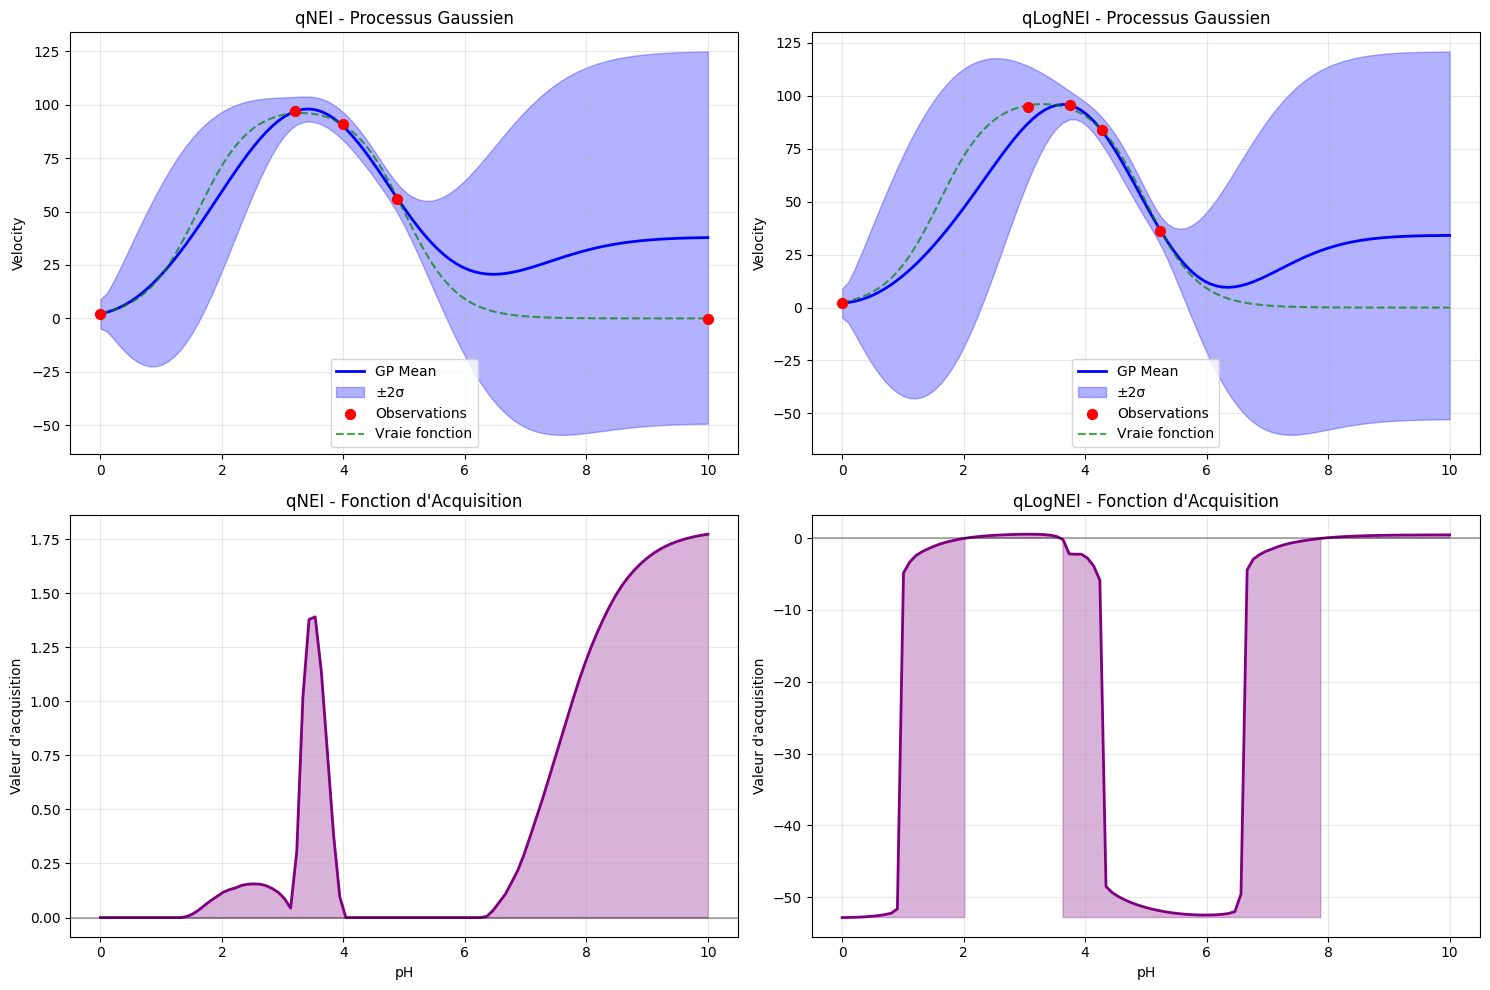

=== Analyse de la convergence === with MC_SAMPLES = 500


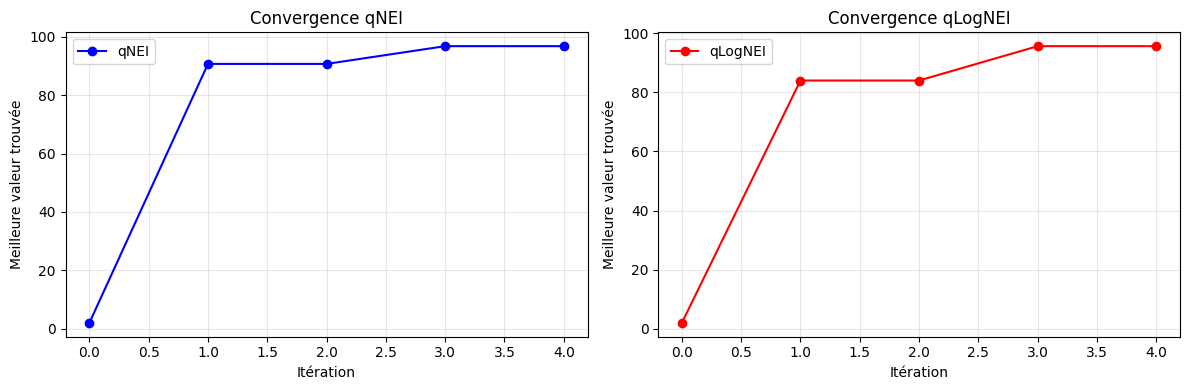

qNEI - Meilleure valeur: 96.839
qLogNEI - Meilleure valeur: 95.653
qNEI - Points explorés: 5
qLogNEI - Points explorés: 5


In [33]:
# Comparaison des deux méthodes
print("=== Comparaison des méthodes qNEI et qLogNEI ===")
compare_methods(model_nei, model_lognei, qNEI, qlogNEI, bounds, 
               train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

# Analyser la convergence
print("=== Analyse de la convergence === with MC_SAMPLES = 500")
plot_convergence(train_x_nei, y_obs_nei, train_x_lognei, y_obs_lognei)

2. Bayes_opt

In [97]:
from bayes_opt import BayesianOptimization

In [ ]:
# Bounded region of parameter space
pbounds = {'x': (0,10)}

optimizer = BayesianOptimization(
    f=fraction_active,
    pbounds=pbounds,
    verbose=2,
    random_state=1
)

In [100]:
optimizer.maximize(
    init_points=6,
    n_iter=3
)

|   iter    |  target   |     x     |
-------------------------------------
| 1         | 85.387207 | 4.1702200 |
| 2         | 0.8386682 | 7.2032449 |
| 3         | 3.4409913 | 0.0011437 |
| 4         | 94.814998 | 3.0233257 |
| 5         | 41.863553 | 1.4675589 |
| 6         | 17.075995 | 0.9233859 |
| 7         | -0.459639 | 10.0      |
| 8         | 94.219303 | 3.5175874 |
| 9         | 97.459472 | 3.2433150 |


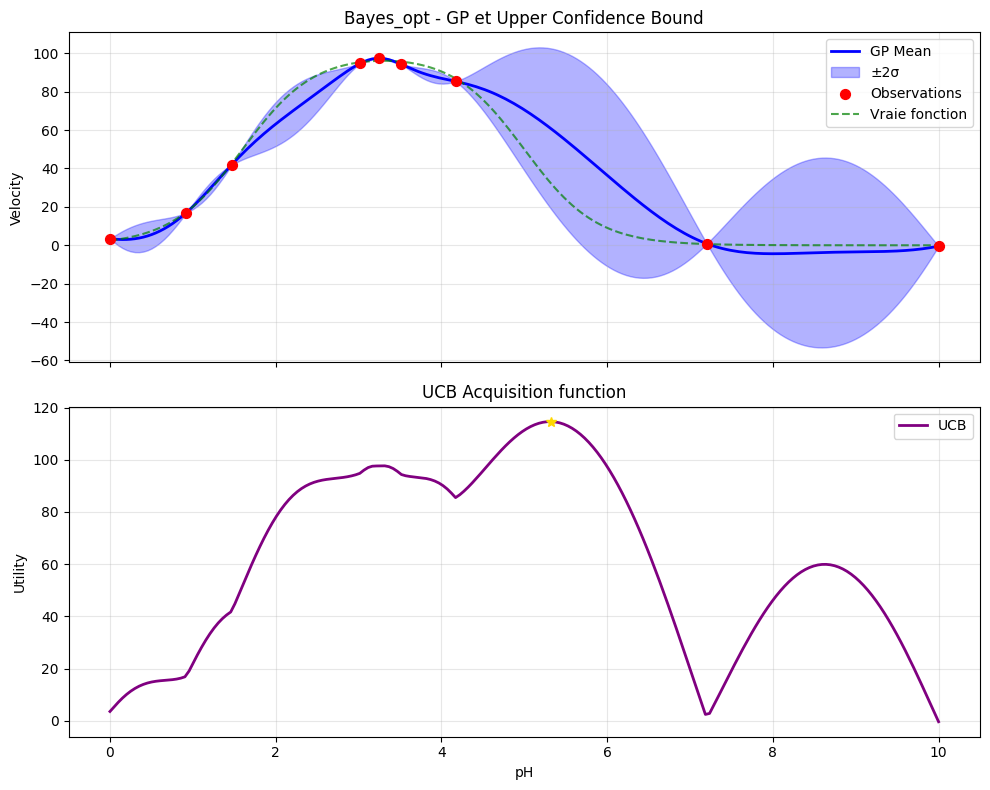

Prochain point suggéré par UCB: pH = 5.327
Prochain point suggéré par EI: pH = 5.226


In [ ]:
# Fonction d'acquisition pour bayes_opt
def plot_acquisition_bayes_opt(optimizer, bounds=(0, 10)):
    """
    This functions allows to visualize the acquisition function and the surrogate model
    Args: 
        optimizer: Bayes_opt optimizer
        bounds: Research space
    
    Returns: 
        plots of the surrogate model and acquisition function
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern
    from scipy.stats import norm
    
    # Extraire les données d'observation
    X_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])
    
    # Créer une grille de points pour l'évaluation
    X_test = np.linspace(bounds[0], bounds[1], 200).reshape(-1, 1)
    
    # Recréer le GP
    kernel = Matern(length_scale=1.0, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
    gp.fit(X_obs, y_obs)
    
    # Prédire la moyenne et l'écart-type
    y_pred, y_std = gp.predict(X_test, return_std=True)
    
    # Calculer l'Upper Confidence Bound (UCB) - fonction d'acquisition par défaut de bayes_opt
    kappa = 2.576  # paramètre par défaut de bayes_opt
    ucb = y_pred + kappa * y_std
    
    # Calculer Expected Improvement (EI) pour comparaison
    f_max = np.max(y_obs)
    xi = 0.01  # paramètre d'exploration
    improvement = y_pred - f_max - xi
    Z = improvement / y_std
    ei = improvement * norm.cdf(Z) + y_std * norm.pdf(Z)
    ei[y_std == 0.0] = 0.0
    
    # Créer le graphique
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    
    # Graphique 1: GP avec UCB
    ax1.plot(X_test.flatten(), y_pred, 'b-', label='GP Mean', linewidth=2)
    ax1.fill_between(X_test.flatten(), 
                     y_pred - 2*y_std, 
                     y_pred + 2*y_std,
                     alpha=0.3, color='blue', label='±2σ')
    #ax1.plot(X_test.flatten(), ucb, 'r-', label='UCB (acquisition)', linewidth=2)
    ax1.scatter(X_obs.flatten(), y_obs, c='red', s=50, zorder=5, label='Observations')
    
    # Vraie fonction
    x_true = np.linspace(bounds[0], bounds[1], 200)
    y_true = fraction_active_true(x_true)
    ax1.plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction')
    
    ax1.set_ylabel('Velocity')
    ax1.set_title('Bayes_opt - GP et Upper Confidence Bound')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Graphique 2: Fonction d'acquisition 
    ucb.argmax()
    ax2.plot(X_test.flatten(), ucb, 'purple', linewidth=2, label='UCB')
    ax2.plot(X_test.flatten()[ucb.argmax()], ucb.max(), marker='*', markersize=7, color='gold')
    #ax2.fill_between(X_test.flatten(), 0, ei, alpha=0.3, color='purple')
    ax2.set_xlabel('pH')
    ax2.set_ylabel('Utility')
    ax2.set_title('UCB Acquisition function')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Trouver le prochain point suggéré par UCB
    next_point_ucb = X_test[np.argmax(ucb)].flatten()[0]
    next_point_ei = X_test[np.argmax(ei)].flatten()[0]
    
    print(f"Prochain point suggéré par UCB: pH = {next_point_ucb:.3f}")
    print(f"Prochain point suggéré par EI: pH = {next_point_ei:.3f}")


# Visualiser la fonction d'acquisition
plot_acquisition_bayes_opt(optimizer, bounds=(0, 10))

In [ ]:
# Comparaison entre bayes_opt et BoTorch
def compare_all_methods():
    """
    Compare les trois approches d'optimisation bayésienne
    """
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    
    # Données pour bayes_opt
    X_bayes_opt = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_bayes_opt = np.array([res["target"] for res in optimizer.res])
    
    # Grille commune pour tous
    x_plot = np.linspace(0, 10, 200)
    x_true = fraction_active_true(x_plot)
    
    # Row 1: GP predictions
    # BoTorch qNEI
    model_nei.eval()
    with torch.no_grad():
        X_test_torch = torch.linspace(0, 10, 200).unsqueeze(-1)
        posterior_nei = model_nei.posterior(X_test_torch)
        mean_nei = posterior_nei.mean.squeeze().numpy()
        std_nei = torch.sqrt(posterior_nei.variance.squeeze()).numpy()
    
    axes[0,0].plot(x_plot, mean_nei, 'b-', linewidth=2, label='GP Mean')
    axes[0,0].fill_between(x_plot, mean_nei - 2*std_nei, mean_nei + 2*std_nei, 
                          alpha=0.3, color='blue', label='±2σ')
    axes[0,0].scatter(train_x_nei.squeeze().numpy(), y_obs_nei.squeeze().numpy(), 
                     c='red', s=40, zorder=5, label='Observations')
    axes[0,0].plot(x_plot, x_true, 'g--', alpha=0.7, label='Vraie fonction')
    axes[0,0].set_title('BoTorch qNEI')
    axes[0,0].set_ylabel('Velocity')
    axes[0,0].legend()
    axes[0,0].grid(True, alpha=0.3)
    
    # BoTorch qLogNEI
    model_lognei.eval()
    with torch.no_grad():
        posterior_lognei = model_lognei.posterior(X_test_torch)
        mean_lognei = posterior_lognei.mean.squeeze().numpy()
        std_lognei = torch.sqrt(posterior_lognei.variance.squeeze()).numpy()
    
    axes[0,1].plot(x_plot, mean_lognei, 'b-', linewidth=2, label='GP Mean')
    axes[0,1].fill_between(x_plot, mean_lognei - 2*std_lognei, mean_lognei + 2*std_lognei, 
                          alpha=0.3, color='blue', label='±2σ')
    axes[0,1].scatter(train_x_lognei.squeeze().numpy(), y_obs_lognei.squeeze().numpy(), 
                     c='red', s=40, zorder=5, label='Observations')
    axes[0,1].plot(x_plot, x_true, 'g--', alpha=0.7, label='Vraie fonction')
    axes[0,1].set_title('BoTorch qLogNEI')
    axes[0,1].legend()
    axes[0,1].grid(True, alpha=0.3)
    
    # bayes_opt
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern
    
    kernel = Matern(length_scale=1.0, nu=2.5)
    gp_bayes = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
    gp_bayes.fit(X_bayes_opt, y_bayes_opt)
    
    X_test_bayes = x_plot.reshape(-1, 1)
    y_pred_bayes, y_std_bayes = gp_bayes.predict(X_test_bayes, return_std=True)
    
    axes[0,2].plot(x_plot, y_pred_bayes, 'b-', linewidth=2, label='GP Mean')
    axes[0,2].fill_between(x_plot, y_pred_bayes - 2*y_std_bayes, y_pred_bayes + 2*y_std_bayes, 
                          alpha=0.3, color='blue', label='±2σ')
    axes[0,2].scatter(X_bayes_opt.flatten(), y_bayes_opt, c='red', s=40, zorder=5, label='Observations')
    axes[0,2].plot(x_plot, x_true, 'g--', alpha=0.7, label='Vraie fonction')
    axes[0,2].set_title('bayes_opt')
    axes[0,2].legend()
    axes[0,2].grid(True, alpha=0.3)
    
    # Row 2: Convergence comparison
    # qNEI convergence
    iterations_nei = range(len(train_x_nei))
    max_values_nei = [y_obs_nei[:i+1].max().item() for i in iterations_nei]
    axes[1,0].plot(iterations_nei, max_values_nei, 'bo-', label='qNEI')
    axes[1,0].set_xlabel('Itération')
    axes[1,0].set_ylabel('Meilleure valeur')
    axes[1,0].set_title('Convergence qNEI')
    axes[1,0].grid(True, alpha=0.3)
    axes[1,0].legend()
    
    # qLogNEI convergence
    iterations_lognei = range(len(train_x_lognei))
    max_values_lognei = [y_obs_lognei[:i+1].max().item() for i in iterations_lognei]
    axes[1,1].plot(iterations_lognei, max_values_lognei, 'ro-', label='qLogNEI')
    axes[1,1].set_xlabel('Itération')
    axes[1,1].set_ylabel('Meilleure valeur')
    axes[1,1].set_title('Convergence qLogNEI')
    axes[1,1].grid(True, alpha=0.3)
    axes[1,1].legend()
    
    # bayes_opt convergence
    iterations_bayes = range(len(y_bayes_opt))
    max_values_bayes = [np.max(y_bayes_opt[:i+1]) for i in iterations_bayes]
    axes[1,2].plot(iterations_bayes, max_values_bayes, 'go-', label='bayes_opt')
    axes[1,2].set_xlabel('Itération')
    axes[1,2].set_ylabel('Meilleure valeur')
    axes[1,2].set_title('Convergence bayes_opt')
    axes[1,2].grid(True, alpha=0.3)
    axes[1,2].legend()
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques comparatives
    print("=== Comparaison finale ===")
    print(f"qNEI (BoTorch):")
    print(f"  - Points explorés: {len(train_x_nei)}")
    print(f"  - Meilleure valeur: {max(max_values_nei):.3f}")
    print(f"  - Meilleur pH: {train_x_nei[y_obs_nei.argmax()].item():.3f}")
    
    print(f"\nqLogNEI (BoTorch):")
    print(f"  - Points explorés: {len(train_x_lognei)}")
    print(f"  - Meilleure valeur: {max(max_values_lognei):.3f}")
    print(f"  - Meilleur pH: {train_x_lognei[y_obs_lognei.argmax()].item():.3f}")
    
    print(f"\nbayes_opt:")
    print(f"  - Points explorés: {len(y_bayes_opt)}")
    print(f"  - Meilleure valeur: {max(max_values_bayes):.3f}")
    print(f"  - Meilleur pH: {optimizer.max['params']['x']:.3f}")
    
    # Valeur théorique optimale
    x_theory = np.linspace(0, 10, 1000)
    y_theory = fraction_active_true(x_theory)
    optimal_ph = x_theory[np.argmax(y_theory)]
    optimal_value = np.max(y_theory)
    print(f"\nOptimum théorique:")
    print(f"  - pH optimal: {optimal_ph:.3f}")
    print(f"  - Valeur optimale: {optimal_value:.3f}")

# Comparaison globale
print("=== Comparaison des trois méthodes ===")
compare_all_methods()

3. PyMC

In [ ]:
pm.util.point_wrapper

In [4]:
import arviz as az
import numpy as np

import matplotlib.pyplot as plt

import pymc as pm
# compile gradient function - need access to raw JAX function to do batching before compilation
# compile_pymc now lives in pytensorf
# https://github.com/pymc-devs/pymc/blob/main/pymc/pytensorf.py
# compilation done by pytensor.function(...)
# this is an alias for pytensor.compile.function.function()
from pymc.initial_point import compile # compile gradient function
#from pymc.util import dataset_to_point_list # create batches of size 1

%load_ext watermark
%watermark -n -u -v -iv -w

ModuleNotFoundError: No module named 'watermark'

In [ ]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

from scipy.special import expit as logistic

import pymc as pm

print(f"Running on PyMC v{pm.__version__}")

In [ ]:
az.style.use("arviz-darkgrid")

RANDOM_SEED = 58
rng = np.random.default_rng(RANDOM_SEED)


def standardize(series):
    """Standardize a pandas series"""
    return (series - series.mean()) / series.std()

In [ ]:
N = 100

true_a, true_b, predictor = 0.5, 3.0, rng.normal(loc=2, scale=6, size=N)
true_mu = true_a + true_b * predictor
true_sd = 2.0

outcome = rng.normal(loc=true_mu, scale=true_sd, size=N)

f"{predictor.mean():.2f}, {predictor.std():.2f}, {outcome.mean():.2f}, {outcome.std():.2f}"

In [ ]:
predictor_scaled = standardize(predictor)
outcome_scaled = standardize(outcome)

f"{predictor_scaled.mean():.2f}, {predictor_scaled.std():.2f}, {outcome_scaled.mean():.2f}, {outcome_scaled.std():.2f}"

In [ ]:
# Visualisation des résultats de bayes_opt
def plot_bayes_opt_results(optimizer, bounds=(0, 10), title="Bayes_opt - GP et Incertitude"):
    """
    Visualise les résultats de l'optimisation bayésienne avec bayes_opt
    
    Args:
        optimizer: objet BayesianOptimization de bayes_opt
        bounds: limites de l'espace de recherche (min, max)
        title: titre du graphique
    """
    import numpy as np
    import matplotlib.pyplot as plt
    from sklearn.gaussian_process import GaussianProcessRegressor
    from sklearn.gaussian_process.kernels import Matern
    
    # Extraire les données d'observation
    X_obs = np.array([[res["params"]["x"]] for res in optimizer.res])
    y_obs = np.array([res["target"] for res in optimizer.res])
    
    # Créer une grille de points pour l'évaluation
    X_test = np.linspace(bounds[0], bounds[1], 200).reshape(-1, 1)
    
    # Recréer un GP similaire à celui utilisé par bayes_opt
    # bayes_opt utilise par défaut un kernel Matern avec nu=2.5
    kernel = Matern(length_scale=1.0, nu=2.5)
    gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True)
    
    # Entraîner le GP sur les données observées
    gp.fit(X_obs, y_obs)
    
    # Prédire la moyenne et l'écart-type
    y_pred, y_std = gp.predict(X_test, return_std=True)
    
    # Créer le graphique
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Tracer la moyenne du GP
    ax.plot(X_test.flatten(), y_pred, 'b-', label='GP Mean', linewidth=2)
    
    # Tracer l'intervalle de confiance (±2σ pour ~95%)
    ax.fill_between(X_test.flatten(), 
                    y_pred - 2*y_std, 
                    y_pred + 2*y_std,
                    alpha=0.3, color='blue', label='±2σ (95% CI)')
    
    # Tracer les points d'observation
    ax.scatter(X_obs.flatten(), y_obs, c='red', s=50, zorder=5, label='Observations')
    
    # Ajouter la vraie fonction pour comparaison
    x_true = np.linspace(bounds[0], bounds[1], 200)
    y_true = fraction_active_true(x_true)
    ax.plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction', linewidth=2)
    
    # Marquer le meilleur point trouvé
    best_x = optimizer.max["params"]["x"]
    best_y = optimizer.max["target"]
    ax.scatter([best_x], [best_y], c='gold', s=100, marker='*', 
               zorder=6, label=f'Meilleur point (pH={best_x:.3f})')
    
    # Configuration du graphique
    ax.set_xlabel('pH')
    ax.set_ylabel('Velocity')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim(bounds[0], bounds[1])
    
    plt.tight_layout()
    plt.show()
    
    # Afficher des statistiques
    print(f"=== Résultats bayes_opt ===")
    print(f"Nombre d'évaluations: {len(optimizer.res)}")
    print(f"Meilleur point: pH = {best_x:.3f}")
    print(f"Meilleure valeur: {best_y:.3f}")
    print(f"Points explorés: {X_obs.flatten()}")
    
    return fig

# Visualiser les résultats de bayes_opt
plot_bayes_opt_results(optimizer, bounds=(0, 10)) with pm.Model() as model_1:
    a = pm.Normal("a", 0.0, 10.0)
    b = pm.Normal("b", 0.0, 10.0)

    mu = a + b * predictor_scaled
    sigma = pm.Exponential("sigma", 1.0)

    pm.Normal("obs", mu=mu, sigma=sigma, observed=outcome_scaled)
    idata = pm.sample_prior_predictive(draws=50, random_seed=rng)

In [ ]:
import pymc as pm

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


In [ ]:
basic_model = pm.Model()

with basic_model:
    # Priors for unknown model parameters
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta = pm.Normal("beta", mu=0, sigma=10, shape=2)
    sigma = pm.HalfNormal("sigma", sigma=1)

    # Expected value of outcome
    mu = alpha + beta[0] * X1 + beta[1] * X2

    # Likelihood (sampling distribution) of observations
    Y_obs = pm.Normal("Y_obs", mu=mu, sigma=sigma, observed=Y)

In [ ]:
import sys
print("Python executable path:")
print(sys.executable)
print(f"Python version: {sys.version}")

Python executable path:
c:\Users\L1116597\AppData\Local\anaconda3\python.exe
Python version: 3.11.5 | packaged by Anaconda, Inc. | (main, Sep 11 2023, 13:26:23) [MSC v.1916 64 bit (AMD64)]


## Comment upgrader une librairie Python

Il existe plusieurs méthodes pour mettre à jour une librairie Python selon votre environnement :

In [ ]:
# 1. Vérifier la version actuelle d'une librairie
def check_library_version(library_name):
    """Vérifie la version actuelle d'une librairie"""
    try:
        if library_name == "arviz":
            import arviz as az
            print(f"arviz version: {az.__version__}")
        elif library_name == "pymc":
            import pymc as pm
            print(f"PyMC version: {pm.__version__}")
        elif library_name == "numpy":
            import numpy as np
            print(f"NumPy version: {np.__version__}")
        elif library_name == "matplotlib":
            import matplotlib
            print(f"Matplotlib version: {matplotlib.__version__}")
        elif library_name == "torch":
            import torch
            print(f"PyTorch version: {torch.__version__}")
        elif library_name == "botorch":
            import botorch
            print(f"BoTorch version: {botorch.__version__}")
        else:
            print(f"Ajoutez {library_name} à la fonction pour vérifier sa version")
    except ImportError:
        print(f"{library_name} n'est pas installé")

# Vérifier les versions actuelles
print("=== Versions actuelles ===")
libraries = ["arviz", "pymc", "numpy", "matplotlib", "torch", "botorch"]
for lib in libraries:
    check_library_version(lib)

### Méthodes pour upgrader une librairie :

#### 1. **Avec pip (Python Package Installer)**
```bash
# Upgrade vers la dernière version
pip install --upgrade nom_librairie
# ou
pip install -U nom_librairie

# Upgrade vers une version spécifique
pip install nom_librairie==version_specifique

# Exemples :
pip install --upgrade arviz
pip install --upgrade pymc
pip install --upgrade numpy
```

#### 2. **Avec conda (si vous utilisez Anaconda/Miniconda)**
```bash
# Upgrade vers la dernière version
conda update nom_librairie

# Upgrade vers une version spécifique
conda install nom_librairie=version_specifique

# Exemples :
conda update arviz
conda update pymc
conda update numpy
```

#### 3. **Dans un Jupyter Notebook avec les commandes magiques**
Vous pouvez exécuter directement dans une cellule :

In [ ]:
# Exemples de commandes à exécuter dans le notebook

# Avec pip (décommentez la ligne que vous voulez utiliser)
# !pip install --upgrade arviz
# !pip install --upgrade pymc  
# !pip install --upgrade numpy
# !pip install --upgrade matplotlib
# !pip install --upgrade torch
# !pip install --upgrade botorch

# Avec conda (si vous utilisez conda)
# !conda update arviz -y
# !conda update pymc -y

print("⚠️ Après un upgrade, redémarrez le kernel du notebook pour que les changements prennent effet!")
print("Dans VS Code: Kernel > Restart Kernel")

In [ ]:
# Fonction pratique pour upgrader une librairie depuis le notebook
def upgrade_library(library_name, use_conda=False):
    """
    Upgrade une librairie Python
    
    Args:
        library_name (str): nom de la librairie
        use_conda (bool): True pour utiliser conda, False pour pip
    """
    import subprocess
    import sys
    
    try:
        if use_conda:
            command = f"conda update {library_name} -y"
            print(f"🔄 Upgrading {library_name} avec conda...")
        else:
            command = f"pip install --upgrade {library_name}"
            print(f"🔄 Upgrading {library_name} avec pip...")
        
        result = subprocess.run(command, shell=True, capture_output=True, text=True)
        
        if result.returncode == 0:
            print(f"✅ {library_name} a été mis à jour avec succès!")
            print("⚠️ Redémarrez le kernel pour que les changements prennent effet.")
        else:
            print(f"❌ Erreur lors de la mise à jour de {library_name}:")
            print(result.stderr)
            
    except Exception as e:
        print(f"❌ Erreur: {e}")

# Exemple d'utilisation (décommentez pour utiliser):
# upgrade_library("arviz")  # Avec pip
# upgrade_library("arviz", use_conda=True)  # Avec conda

### Cas particuliers et bonnes pratiques :

#### **Problèmes avec arviz :**
Si vous avez des problèmes avec `arviz` (comme dans votre code), essayez :

```bash
# 1. Désinstaller puis réinstaller
pip uninstall arviz
pip install arviz

# 2. Ou forcer la réinstallation
pip install --force-reinstall arviz

# 3. Installer une version spécifique stable
pip install arviz==0.15.1
```

#### **Environnements virtuels :**
- **venv** : `python -m pip install --upgrade nom_librairie`
- **conda env** : `conda activate nom_env` puis `conda update nom_librairie`

#### **Vérifier les mises à jour disponibles :**
```bash
# Voir les versions disponibles
pip index versions nom_librairie

# Voir les packages outdated
pip list --outdated
```

#### **⚠️ Points importants :**
1. **Redémarrez toujours le kernel** après un upgrade
2. **Testez votre code** après la mise à jour
3. **Sauvegardez votre environnement** avec `pip freeze > requirements.txt`
4. **Attention aux breaking changes** entre versions majeures

In [ ]:
# Pour votre cas spécifique avec arviz, essayons de corriger l'import
print("=== Diagnostic du problème arviz ===")

try:
    import arviz as az  # Import correct
    print(f"✅ arviz importé correctement: version {az.__version__}")
except ImportError as e:
    print(f"❌ Erreur d'import arviz: {e}")
    print("💡 Solution: !pip install --upgrade arviz")

# Vérifier si c'était une erreur de frappe dans votre code
try:
    # Votre code avait: import arviz as np (erreur!)
    # Cela remplace numpy par arviz, ce qui cause des problèmes
    print("⚠️ Dans votre code, vous avez écrit 'import arviz as np'")
    print("   Cela remplace numpy par arviz!")
    print("   La bonne syntaxe est: 'import arviz as az'")
except:
    pass

print("\n=== Imports corrects ===")
print("import numpy as np      # Pour numpy")
print("import arviz as az      # Pour arviz") 
print("import matplotlib.pyplot as plt  # Pour matplotlib")

## Animation de l'évolution du processus gaussien

Visualisation animée de l'évolution du GP et de son incertitude pendant l'optimisation bayésienne

In [ ]:
import matplotlib.animation as animation
from IPython.display import HTML
import io
import base64

def animate_bayesian_optimization(
    objective_func,
    bounds,
    n_initial=2,
    n_iterations=10,
    acquisition_type='qNEI',
    figsize=(12, 8),
    interval=1500,
    save_gif=False,
    gif_filename='bayesian_opt_animation.gif'
):
    """
    Crée une animation de l'évolution du processus gaussien pendant l'optimisation bayésienne
    
    Args:
        objective_func: fonction objectif à optimiser
        bounds: limites de l'espace de recherche [tensor([[min], [max]])]
        n_initial: nombre de points d'initialisation
        n_iterations: nombre d'itérations d'optimisation
        acquisition_type: type de fonction d'acquisition ('qNEI' ou 'qLogNEI')
        figsize: taille de la figure
        interval: délai entre les frames (ms)
        save_gif: sauvegarder l'animation en GIF
        gif_filename: nom du fichier GIF
    
    Returns:
        animation matplotlib
    """
    
    # Initialisation des données
    x_init = torch.linspace(bounds[0].item(), bounds[1].item(), n_initial).unsqueeze(-1)
    y_init = objective_func(x_init.squeeze()).unsqueeze(-1)
    
    # Grille pour l'évaluation
    x_test = torch.linspace(bounds[0].item(), bounds[1].item(), 200).unsqueeze(-1)
    x_true = np.linspace(bounds[0].item(), bounds[1].item(), 200)
    y_true = fraction_active_true(x_true)
    
    # Stockage des données pour chaque itération
    iterations_data = []
    
    # Points d'entraînement actuels
    train_x = x_init.clone()
    train_y = y_init.clone()
    
    # Stocker l'état initial
    iterations_data.append({
        'train_x': train_x.clone(),
        'train_y': train_y.clone(),
        'iteration': 0
    })
    
    # Effectuer les itérations d'optimisation
    for i in range(n_iterations):
        # Initialiser et entraîner le modèle
        model, mll = initialize_model(train_x, train_y)
        fit_gpytorch_mll(mll)
        
        # Créer la fonction d'acquisition
        qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
        
        if acquisition_type == 'qNEI':
            acq_func = qNoisyExpectedImprovement(
                model=model,
                X_baseline=train_x,
                sampler=qmc_sampler
            )
        else:  # qLogNEI
            acq_func = qLogNoisyExpectedImprovement(
                model=model,
                X_baseline=train_x,
                sampler=qmc_sampler
            )
        
        # Optimiser la fonction d'acquisition
        new_x, new_y = optimize_acqf_and_get_observation(acq_func, bounds)
        
        # Mettre à jour les données d'entraînement
        train_x = torch.cat([train_x, new_x])
        train_y = torch.cat([train_y, new_y])
        
        # Stocker les données de cette itération
        iterations_data.append({
            'train_x': train_x.clone(),
            'train_y': train_y.clone(),
            'iteration': i + 1
        })
    
    # Créer l'animation
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=figsize, sharex=True)
    
    def animate(frame):
        # Nettoyer les axes
        ax1.clear()
        ax2.clear()
        
        data = iterations_data[frame]
        current_train_x = data['train_x']
        current_train_y = data['train_y']
        iteration = data['iteration']
        
        # Reconstruire le modèle pour cette itération
        if len(current_train_x) > 1:
            model, mll = initialize_model(current_train_x, current_train_y)
            fit_gpytorch_mll(mll)
            
            model.eval()
            with torch.no_grad():
                posterior = model.posterior(x_test)
                mean = posterior.mean.squeeze()
                std = torch.sqrt(posterior.variance.squeeze())
                
                # Fonction d'acquisition
                qmc_sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
                if acquisition_type == 'qNEI':
                    acq_func = qNoisyExpectedImprovement(
                        model=model,
                        X_baseline=current_train_x,
                        sampler=qmc_sampler
                    )
                else:
                    acq_func = qLogNoisyExpectedImprovement(
                        model=model,
                        X_baseline=current_train_x,
                        sampler=qmc_sampler
                    )
                
                acq_values = acq_func(x_test.unsqueeze(1)).squeeze()
            
            # Convertir en numpy
            x_np = x_test.squeeze().numpy()
            mean_np = mean.numpy()
            std_np = std.numpy()
            acq_np = acq_values.numpy()
        else:
            # Cas initial : pas assez de points pour un GP
            x_np = x_test.squeeze().numpy()
            mean_np = np.zeros_like(x_np)
            std_np = np.ones_like(x_np) * 10  # Incertitude élevée
            acq_np = np.ones_like(x_np)  # Acquisition uniforme
        
        train_x_np = current_train_x.squeeze().numpy()
        train_y_np = current_train_y.squeeze().numpy()
        
        # Graphique 1: GP et observations
        if len(current_train_x) > 1:
            ax1.plot(x_np, mean_np, 'b-', label='GP Mean', linewidth=2)
            ax1.fill_between(x_np, mean_np - 2*std_np, mean_np + 2*std_np,
                           alpha=0.3, color='blue', label='±2σ (95% CI)')
        
        # Points d'observation avec couleurs selon l'ordre
        colors = plt.cm.viridis(np.linspace(0, 1, len(train_x_np)))
        scatter = ax1.scatter(train_x_np, train_y_np, c=colors, s=60, 
                            zorder=5, label='Observations', edgecolors='black', linewidth=1)
        
        # Marquer le dernier point ajouté
        if iteration > 0:
            ax1.scatter(train_x_np[-1], train_y_np[-1], c='red', s=100, 
                       marker='*', zorder=6, label='Nouveau point', edgecolors='black')
        
        # Vraie fonction
        ax1.plot(x_true, y_true, 'g--', alpha=0.7, label='Vraie fonction', linewidth=2)
        
        # Configuration
        ax1.set_ylabel('Velocity')
        ax1.set_title(f'{acquisition_type} - Itération {iteration} - GP et Observations ({len(train_x_np)} points)')
        ax1.legend()
        ax1.grid(True, alpha=0.3)
        ax1.set_ylim(-20, 120)
        
        # Graphique 2: Fonction d'acquisition
        if len(current_train_x) > 1:
            ax2.plot(x_np, acq_np, 'purple', linewidth=2, label='Fonction d\'acquisition')
            ax2.fill_between(x_np, 0, acq_np, where=(acq_np >= 0), 
                           alpha=0.3, color='purple', interpolate=True)
            if np.any(acq_np < 0):
                ax2.fill_between(x_np, acq_np.min(), acq_np, where=(acq_np < 0), 
                               alpha=0.3, color='red', interpolate=True)
            ax2.axhline(y=0, color='black', linestyle='-', alpha=0.3)
            
            # Marquer le maximum de la fonction d'acquisition
            max_idx = np.argmax(acq_np)
            ax2.scatter(x_np[max_idx], acq_np[max_idx], c='gold', s=100, 
                       marker='*', zorder=6, label='Maximum d\'acquisition')
        
        ax2.set_xlabel('pH')
        ax2.set_ylabel('Valeur d\'acquisition')
        ax2.set_title('Fonction d\'Acquisition')
        ax2.legend()
        ax2.grid(True, alpha=0.3)
        ax2.set_xlim(bounds[0].item(), bounds[1].item())
        
        # Statistiques
        if len(train_y_np) > 0:
            best_value = np.max(train_y_np)
            best_x = train_x_np[np.argmax(train_y_np)]
            fig.suptitle(f'Optimisation Bayésienne - Meilleure valeur: {best_value:.2f} (pH={best_x:.2f})', 
                        fontsize=14, fontweight='bold')
        
        plt.tight_layout()
    
    # Créer l'animation
    anim = animation.FuncAnimation(
        fig, animate, frames=len(iterations_data), 
        interval=interval, repeat=True, blit=False
    )
    
    # Sauvegarder en GIF si demandé
    if save_gif:
        print(f"💾 Sauvegarde de l'animation en {gif_filename}...")
        writergif = animation.PillowWriter(fps=1000/interval)
        anim.save(gif_filename, writer=writergif)
        print(f"✅ Animation sauvegardée: {gif_filename}")
    
    return anim

print("✅ Fonction d'animation créée avec succès!")

In [ ]:
# Exemple d'utilisation de l'animation
def demo_animation():
    """
    Démonstration de l'animation de l'optimisation bayésienne
    """
    print("🎬 Création de l'animation de l'optimisation bayésienne...")
    print("⏳ Cela peut prendre quelques secondes...")
    
    # Paramètres de l'animation
    bounds_demo = torch.tensor([[0.], [8.]], dtype=float)
    
    # Créer l'animation avec qNEI
    anim_nei = animate_bayesian_optimization(
        objective_func=fraction_active,
        bounds=bounds_demo,
        n_initial=2,           # Commencer avec 2 points
        n_iterations=8,        # 8 itérations d'optimisation
        acquisition_type='qNEI',
        figsize=(12, 8),
        interval=2000,         # 2 secondes entre les frames
        save_gif=False         # Mettre True pour sauvegarder
    )
    
    print("✅ Animation créée! L'animation va se lancer...")
    plt.show()
    
    return anim_nei

# Lancer la démonstration
print("=== Animation de l'optimisation bayésienne avec qNEI ===")
animation_nei = demo_animation()

In [ ]:
# Animation comparative: qNEI vs qLogNEI
def compare_animations():
    """
    Compare les animations des deux méthodes côte à côte
    """
    print("🎬 Création d'animations comparatives...")
    
    bounds_demo = torch.tensor([[0.], [8.]], dtype=float)
    
    # Animation qLogNEI
    print("📊 Animation avec qLogNEI...")
    anim_lognei = animate_bayesian_optimization(
        objective_func=fraction_active,
        bounds=bounds_demo,
        n_initial=2,
        n_iterations=8,
        acquisition_type='qLogNEI',
        figsize=(12, 8),
        interval=2000,
        save_gif=False
    )
    
    plt.show()
    return anim_lognei

# Lancer la comparaison
print("=== Animation de l'optimisation bayésienne avec qLogNEI ===")
animation_lognei = compare_animations()

In [ ]:
# Animation avancée avec options de sauvegarde
def create_custom_animation(
    acquisition='qNEI', 
    n_points=3, 
    n_iter=10, 
    save_gif=True,
    filename=None
):
    """
    Crée une animation personnalisée avec options avancées
    
    Args:
        acquisition: 'qNEI' ou 'qLogNEI'
        n_points: nombre de points initiaux
        n_iter: nombre d'itérations
        save_gif: sauvegarder en GIF
        filename: nom du fichier (auto si None)
    """
    
    if filename is None:
        filename = f"bayesian_opt_{acquisition}_{n_points}pts_{n_iter}iter.gif"
    
    print(f"🎬 Création d'une animation personnalisée:")
    print(f"   - Méthode: {acquisition}")
    print(f"   - Points initiaux: {n_points}")
    print(f"   - Itérations: {n_iter}")
    if save_gif:
        print(f"   - Sauvegarde: {filename}")
    
    bounds_demo = torch.tensor([[0.], [8.]], dtype=float)
    
    anim = animate_bayesian_optimization(
        objective_func=fraction_active,
        bounds=bounds_demo,
        n_initial=n_points,
        n_iterations=n_iter,
        acquisition_type=acquisition,
        figsize=(12, 8),
        interval=1500,
        save_gif=save_gif,
        gif_filename=filename
    )
    
    plt.show()
    return anim

# Exemples d'utilisation personnalisée (décommentez pour utiliser)
# animation_custom = create_custom_animation('qNEI', n_points=2, n_iter=6, save_gif=True)
# animation_custom = create_custom_animation('qLogNEI', n_points=3, n_iter=8, save_gif=False)

print("✅ Fonctions d'animation avancées créées!")

### Guide d'utilisation des animations

#### **Fonctions principales :**

1. **`animate_bayesian_optimization()`** - Fonction principale
   - Crée une animation complète de l'optimisation bayésienne
   - Paramètres personnalisables (points initiaux, itérations, type d'acquisition)

2. **`demo_animation()`** - Démonstration simple
   - Lance une animation avec paramètres par défaut
   - Idéal pour un premier test

3. **`compare_animations()`** - Comparaison des méthodes
   - Permet de comparer qNEI et qLogNEI

4. **`create_custom_animation()`** - Animation personnalisée
   - Options avancées de configuration
   - Sauvegarde en GIF possible

#### **Ce que montrent les animations :**

- **Panneau supérieur** : Évolution du GP et des observations
  - Ligne bleue : moyenne du GP
  - Zone bleue : intervalle de confiance ±2σ
  - Points colorés : observations (du plus ancien au plus récent)
  - Étoile rouge : nouveau point à chaque itération
  - Ligne verte : vraie fonction

- **Panneau inférieur** : Fonction d'acquisition
  - Ligne violette : valeur de la fonction d'acquisition
  - Étoile dorée : point où la fonction d'acquisition est maximale
  - Zone colorée : régions d'intérêt pour l'exploration

#### **Options importantes :**

- `interval` : Délai entre les frames (ms)
- `save_gif` : Sauvegarde en fichier GIF
- `n_initial` : Nombre de points de départ
- `n_iterations` : Nombre d'itérations d'optimisation